In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import warnings
import time, math, os
warnings.filterwarnings('ignore')

In [2]:
TRAIN_PATH     = 'train.csv'
TEST_PATH      = 'test.csv'
SONG_PATH      = 'song_data.csv'
SAMPLE_PATH    = 'sample_submission.csv'
OUT_DIR    = 'cmpe256'

In [3]:
train_dtypes = {'user_id': 'int32', 'song_id': 'int32', 'rating': 'float32'}
test_dtypes = {'user_id': 'int32', 'song_id': 'int32'}

In [5]:
train = pd.read_csv(TRAIN_PATH, dtype=train_dtypes)

test  = pd.read_csv(TEST_PATH,  dtype=test_dtypes)

songs = pd.read_csv(SONG_PATH)

TRAIN shape: (5318229, 3)
user_id      int32
song_id      int32
rating     float32
dtype: object
   user_id  song_id  rating
0  1257279  1133436    4.25
1  1521617  1041044    2.75
2  1757741  1018376    4.25
3  1311545  1035650    5.25
4  1633733  1080634    8.25

TEST shape: (1063645, 2)
   user_id  song_id
0  1717534  1005189
1  1302257  1042789
2  1700269  1042495

SONG DATA shape: (198724, 5)
   song_id              title                    release       artist_name  \
0  1191338       Silent Night      Monster Ballads X-Mas  Faster Pussy cat   
1  1178322      L'antarctique  Des cobras des tarentules  3 Gars Su'l Sofa   
2  1052052  Ethos of Coercion     Descend Into Depravity       Dying Fetus   

   year  
0  2003  
1  2007  
2  2009  
RATING STATISTICS
  min     : 1.0
  max     : 10.0
  mean    : 5.3700
  median  : 4.75
  std     : 1.7252


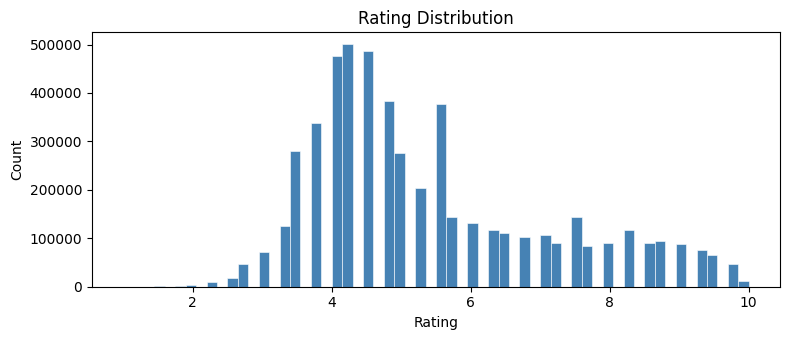

→ Saved rating_distribution.png

USER / ITEM COVERAGE
  Train unique users : 755,695
  Train unique songs : 185,615
  Test  unique users : 454,023
  Test  unique songs : 112,998

  Cold-start USERS (in test, not train): 23,554  (5.2%)
  Cold-start SONGS (in test, not train): 7,958  (7.0%)

  Test rows with cold-start user : 27,346  (2.6%)
  Test rows with cold-start song : 8,808  (0.8%)


In [6]:

# print(train.head())

# print(test.head())

# print(songs.head())

print("TRAIN shape:", train.shape)
print(train.dtypes)
print(train.head(5))
print("\nTEST shape:", test.shape)
print(test.head(3))
print("\nSONG DATA shape:", songs.shape)
print(songs.head(3))

# 3. RATING SCALE ANALYSIS  ←  for model setup
r = train['rating']

print("RATING STATISTICS")
print(f"  min     : {r.min()}")
print(f"  max     : {r.max()}")
print(f"  mean    : {r.mean():.4f}")
print(f"  median  : {r.median()}")
print(f"  std     : {r.std():.4f}")


# Distribution of ratings
fig, ax = plt.subplots(figsize=(8, 3.5))

plt.hist(r, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Rating Distribution')
plt.tight_layout()
plt.savefig('rating_distribution.png', bbox_inches='tight')
plt.show()
print("→ Saved rating_distribution.png")



# 4. USER / ITEM COVERAGE to find cold start problem
train_users = set(train['user_id'].unique())
train_songs = set(train['song_id'].unique())
test_users  = set(test['user_id'].unique())
test_songs  = set(test['song_id'].unique())
train_songs = set(train['song_id'].unique())
test_users  = set(test['user_id'].unique())
test_songs  = set(test['song_id'].unique())

print("\n" + "=" * 50)
print("USER / ITEM COVERAGE")
print(f"  Train unique users : {len(train_users):,}")
print(f"  Train unique songs : {len(train_songs):,}")
print(f"  Test  unique users : {len(test_users):,}")
print(f"  Test  unique songs : {len(test_songs):,}")

cold_users = test_users - train_users
cold_songs = test_songs - train_songs
print(f"\n  Cold-start USERS (in test, not train): {len(cold_users):,}  "
      f"({100*len(cold_users)/len(test_users):.1f}%)")
print(f"  Cold-start SONGS (in test, not train): {len(cold_songs):,}  "
      f"({100*len(cold_songs)/len(test_songs):.1f}%)")

# Count test rows affected by cold-start
cold_user_rows = test[test['user_id'].isin(cold_users)].shape[0]
cold_song_rows = test[test['song_id'].isin(cold_songs)].shape[0]
print(f"\n  Test rows with cold-start user : {cold_user_rows:,}  "
      f"({100*cold_user_rows/len(test):.1f}%)")
print(f"  Test rows with cold-start song : {cold_song_rows:,}  "
      f"({100*cold_song_rows/len(test):.1f}%)")


The rating distribution peaks at 4–4.75 but the scale goes to 10 with std=1.73 — that's a wide prediction range. Any model that doesn't learn per-user taste well will struggle. The right-skew also means we'll need to be careful about bias toward mid-range predictions.

# Approach 1 : SVD baseline,  from scratch

Mini-batch gradient descent loop for bias and factor updates.  Equation structure (bias regularization + factor update) was verified with Claude Sonnet 4.6 to match the original Simon Funk formulation.


Source + AI Citation: https://sifter.org/simon/journal/20061211.html

Loading train.csv in chunks …

Train: (5318229, 3) | Test: (1063645, 2) | Songs: (198724, 5)
Global mean: 5.3700  |  range: [1.0, 10.0]
Vocabulary: 779,249 users | 193,573 songs
Train split: 4,786,201 | Val split: 532,028

▶  f=60  rb=0.10
  best val RMSE : 1.7170
  avg epoch time: 4.5s

▶  f=100 rb=0.10
  best val RMSE : 1.7172
  avg epoch time: 6.4s

▶  f=100 rb=0.06
  best val RMSE : 1.7171
  avg epoch time: 6.4s

▶  f=150 rb=0.10
  best val RMSE : 1.7171
  avg epoch time: 9.8s

SWEEP RESULTS (sorted by val RMSE):
  f=60  rb=0.10         val RMSE=1.7170  (4.5s/ep)
  f=100 rb=0.06         val RMSE=1.7171  (6.4s/ep)
  f=150 rb=0.10         val RMSE=1.7171  (9.8s/ep)
  f=100 rb=0.10         val RMSE=1.7172  (6.4s/ep)

BEST CONFIG: f=60  rb=0.10  →  1.7170

Retraining best config on FULL train (5.3M rows) …
Ep  1/30  train=1.7012  val=1.7047  4.9s
Ep  2/30  train=1.6936  val=1.6972  5.0s
Ep  3/30  train=1.6883  val=1.6921  4.8s
Ep  4/30  train=1.6832  val=1.6882  4.9s
Ep  5/30  train=1.

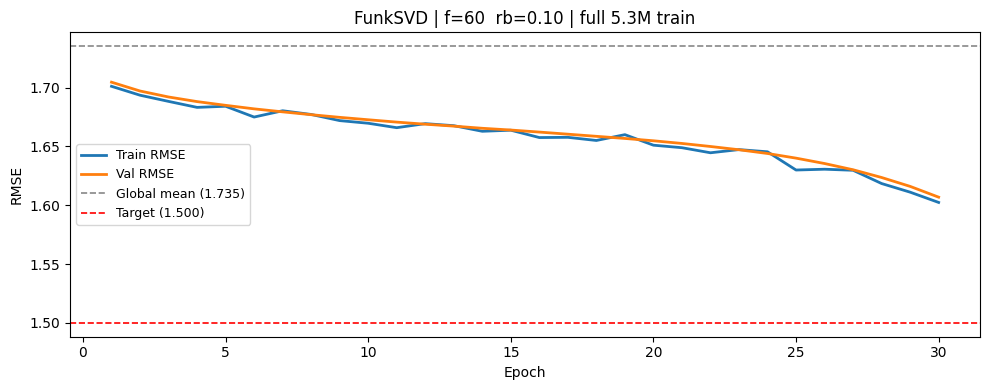

  Sweep best val RMSE  : 1.7170
  Full retrain val RMSE: 1.6069
  Global mean baseline : 1.7353
  Gap to target (1.5)  : 0.1069
  Avg epoch time       : 4.9s


In [ ]:
print("Loading train.csv in chunks …")
chunks = []
for chunk in pd.read_csv(
        TRAIN_PATH,
        dtype={'user_id':'int32', 'song_id':'int32', 'rating':'float32'},
        chunksize=500_000):
    chunks.append(chunk)
    print(f"  {sum(len(c) for c in chunks):,} rows", end='\r')

train = pd.concat(chunks, ignore_index=True)
test  = pd.read_csv(TEST_PATH,  dtype={'user_id':'int32','song_id':'int32'})
songs = pd.read_csv(SONG_PATH)

print(f"\nTrain: {train.shape} | Test: {test.shape} | Songs: {songs.shape}")
assert len(train) > 5_000_000, f"Still got partial load: {len(train):,} rows — re-upload train.csv"


#  GLOBAL STATS
GLOBAL_MEAN = float(train['rating'].mean())
R_MIN, R_MAX = 1.0, 10.0
print(f"Global mean: {GLOBAL_MEAN:.4f}  |  range: [{R_MIN}, {R_MAX}]")

# Song-level and user-level means → used for cold fallback
song_mean = train.groupby('song_id')['rating'].mean()
user_mean = train.groupby('user_id')['rating'].mean()



#   ENCODE IDs
# Build encoding from BOTH train and test so cold-start rows
# get an index (embedding will be ~zero → falls back to biases).

all_users = np.union1d(train['user_id'].unique(), test['user_id'].unique())
all_songs = np.union1d(train['song_id'].unique(), test['song_id'].unique())

user2idx = {int(u): i for i, u in enumerate(all_users)}
song2idx = {int(s): i for i, s in enumerate(all_songs)}

N_USERS = len(user2idx)
N_SONGS = len(song2idx)
print(f"Vocabulary: {N_USERS:,} users | {N_SONGS:,} songs")

train['u'] = train['user_id'].map(user2idx).astype('int32')
train['s'] = train['song_id'].map(song2idx).astype('int32')
test['u']  = test['user_id'].map(user2idx).astype('int32')
test['s']  = test['song_id'].map(song2idx).astype('int32')


#  TRAIN / VAL SPLIT  (stratified by user activity bin)
# Simple random 90/10 — 530K val rows is statistically solid.
np.random.seed(42)
val_mask = np.random.rand(len(train)) < 0.10
trn = train[~val_mask].reset_index(drop=True)
val = train[ val_mask].reset_index(drop=True)

u_t = trn['u'].values.astype('int32')
s_t = trn['s'].values.astype('int32')
r_t = trn['rating'].values.astype('float32')

u_v = val['u'].values.astype('int32')
s_v = val['s'].values.astype('int32')
r_v = val['rating'].values.astype('float32')

print(f"Train split: {len(trn):,} | Val split: {len(val):,}")


# 2.5  FUNK SVD CLASS  (from scratch)


class FunkSVD:
    def __init__(self, n_factors=100, n_epochs=30,
                 lr=0.005, reg_bias=0.10, reg_factors=0.08,
                 r_min=1.0, r_max=10.0, seed=42):
        self.nf  = n_factors
        self.ne  = n_epochs
        self.lr  = np.float32(lr)
        self.rb  = np.float32(reg_bias)
        self.rf  = np.float32(reg_factors)
        self.r_min = r_min
        self.r_max = r_max
        self.rng = np.random.default_rng(seed)

    # ── internal helpers ─────────────────────────────────────
    def _rmse(self, u, s, r):
        p = np.clip(
            self.mu + self.b_u[u] + self.b_s[s]
            + (self.P[u] * self.Q[s]).sum(axis=1),
            self.r_min, self.r_max)
        return math.sqrt(float(((r - p) ** 2).mean()))

    # ── main fit ─────────────────────────────────────────────
    def fit(self, u, s, r, n_users, n_songs,
            val_u=None, val_s=None, val_r=None,
            verbose=True):

        self.mu = np.float32(r.mean())

        self.b_u = np.zeros(n_users, dtype=np.float32)
        self.b_s = np.zeros(n_songs, dtype=np.float32)
        self.P   = (self.rng.standard_normal((n_users, self.nf))
                    * np.float32(0.01)).astype(np.float32)
        self.Q   = (self.rng.standard_normal((n_songs,  self.nf))
                    * np.float32(0.01)).astype(np.float32)

        n     = len(u)
        lr    = self.lr
        rb    = self.rb
        rf    = self.rf
        BATCH = 8192
        self.history = []

        for ep in range(self.ne):
            t0  = time.time()
            idx = self.rng.permutation(n)
            ue, se, re = u[idx], s[idx], r[idx]

            for st in range(0, n, BATCH):
                ub  = ue[st:st+BATCH]
                sb  = se[st:st+BATCH]
                rb_ = re[st:st+BATCH]

                dot  = (self.P[ub] * self.Q[sb]).sum(axis=1)
                err  = rb_ - (self.mu + self.b_u[ub]
                               + self.b_s[sb] + dot)

                self.b_u[ub] += lr * (err - rb * self.b_u[ub])
                self.b_s[sb] += lr * (err - rb * self.b_s[sb])

                Pu = self.P[ub].copy()
                self.P[ub] += lr * (err[:,None] * self.Q[sb]
                                    - rf * self.P[ub])
                self.Q[sb] += lr * (err[:,None] * Pu
                                    - rf * self.Q[sb])

            # ── epoch metrics ────────────────────────────────
            samp     = self.rng.integers(0, n, min(200_000, n))
            tr_rmse  = self._rmse(u[samp], s[samp], r[samp])
            val_rmse = self._rmse(val_u, val_s, val_r) \
                       if val_u is not None else None
            dt = time.time() - t0

            rec = {'ep': ep+1, 'tr': tr_rmse, 'vl': val_rmse, 'dt': dt}
            self.history.append(rec)

            if verbose:
                line = (f"Ep {ep+1:>2}/{self.ne}  "
                        f"train={tr_rmse:.4f}")
                if val_rmse:
                    line += f"  val={val_rmse:.4f}"
                line += f"  {dt:.1f}s"
                print(line)

        return self

    # ── inference ────────────────────────────────────────────
    def predict(self, u, s):
        return np.clip(
            self.mu + self.b_u[u] + self.b_s[s]
            + (self.P[u] * self.Q[s]).sum(axis=1),
            self.r_min, self.r_max).astype(np.float32)


#  HYPERPARAMETER SWEEP  (4 configs × 20 epochs)

SWEEP_CONFIGS = [
    # label,          n_factors, lr,    reg_b, reg_f
    ('f=60  rb=0.10', 60,  0.005, 0.10, 0.08),
    ('f=100 rb=0.10', 100, 0.005, 0.10, 0.08),   # ← reference
    ('f=100 rb=0.06', 100, 0.005, 0.06, 0.06),   # lower reg
    ('f=150 rb=0.10', 150, 0.005, 0.10, 0.08),   # bigger model
]

sweep_log = []
for (label, nf, lr, rb, rf) in SWEEP_CONFIGS:
    print(f"\n{'='*55}\n▶  {label}")
    m = FunkSVD(n_factors=nf, n_epochs=20,
                lr=lr, reg_bias=rb, reg_factors=rf)
    m.fit(u_t, s_t, r_t, N_USERS, N_SONGS,
          val_u=u_v, val_s=s_v, val_r=r_v,
          verbose=False)

    best_val = min(h['vl'] for h in m.history if h['vl'])
    final_ep = m.history[-1]
    avg_epoch_sec = np.mean([h['dt'] for h in m.history])
    print(f"  best val RMSE : {best_val:.4f}")
    print(f"  avg epoch time: {avg_epoch_sec:.1f}s")
    sweep_log.append({
        'label': label, 'val_rmse': best_val,
        'model': m, 'avg_sec': avg_epoch_sec
    })

sweep_log.sort(key=lambda x: x['val_rmse'])

print("\n" + "="*55)
print("SWEEP RESULTS (sorted by val RMSE):")
for r in sweep_log:
    print(f"  {r['label']:20s}  val RMSE={r['val_rmse']:.4f}  "
          f"({r['avg_sec']:.1f}s/ep)")

BEST = sweep_log[0]
print(f"\nBEST CONFIG: {BEST['label']}  →  {BEST['val_rmse']:.4f}")


#   RETRAIN BEST CONFIG ON FULL TRAIN
print(f"\n{'='*55}")
print("Retraining best config on FULL train (5.3M rows) …")

# Parse best config params
best_cfg = next(c for c in SWEEP_CONFIGS if c[0] == BEST['label'])
_, nf_best, lr_best, rb_best, rf_best = best_cfg

final_model = FunkSVD(
    n_factors=nf_best, n_epochs=30,
    lr=lr_best, reg_bias=rb_best, reg_factors=rf_best
)
final_model.fit(
    train['u'].values.astype('int32'),
    train['s'].values.astype('int32'),
    train['rating'].values.astype('float32'),
    N_USERS, N_SONGS,
    val_u=u_v, val_s=s_v, val_r=r_v,   # monitor only, not stopping
    verbose=True
)

best_val_full = min(h['vl'] for h in final_model.history if h['vl'])
print(f"\nFinal model best val RMSE: {best_val_full:.4f}")



#  SUBMISSION


print("\nGenerating submission …")

raw_preds = final_model.predict(
    test['u'].values.astype('int32'),
    test['s'].values.astype('int32')
)

# Cold-start override: if song not in train, use song mean from metadata
cold_song_mask = ~test['song_id'].isin(song_mean.index)
cold_user_mask = ~test['user_id'].isin(user_mean.index)
print(f"Cold songs in test: {cold_song_mask.sum():,} "
      f"| Cold users in test: {cold_user_mask.sum():,}")

for i in test[cold_song_mask].index:
    sid = test.loc[i, 'song_id']
    uid = test.loc[i, 'user_id']
    s_fall = float(song_mean.get(sid, GLOBAL_MEAN))
    u_fall = float(user_mean.get(uid, GLOBAL_MEAN))
    raw_preds[i] = np.clip(0.5*s_fall + 0.5*u_fall, R_MIN, R_MAX)

submission = pd.DataFrame({
    'user_id-song_id': (test['user_id'].astype(str) + '-'
                         + test['song_id'].astype(str)),
    'rating': np.round(raw_preds, 4)
})
out_path = OUT_DIR + 'submission_step2_svd.csv'
submission.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(submission.describe())


#  LEARNING CURVE
hist = final_model.history
eps  = [h['ep'] for h in hist]
trs  = [h['tr'] for h in hist]
vls  = [h['vl'] for h in hist]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(eps, trs, lw=2, label='Train RMSE')
ax.plot(eps, vls, lw=2, label='Val RMSE')
ax.axhline(1.7353, color='#888', ls='--', lw=1.2, label='Global mean (1.735)')
ax.axhline(1.5,    color='red',  ls='--', lw=1.2, label='Target (1.500)')
ax.set_xlabel('Epoch'); ax.set_ylabel('RMSE')
ax.set_title(f'FunkSVD | {BEST["label"]} | full 5.3M train')
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig(OUT_DIR + 'step2_svd_curve.png', bbox_inches='tight')
plt.show()

print(f"  Sweep best val RMSE  : {BEST['val_rmse']:.4f}")
print(f"  Full retrain val RMSE: {best_val_full:.4f}")
print(f"  Global mean baseline : 1.7353")
print(f"  Gap to target (1.5)  : {best_val_full - 1.5:.4f}")
print(f"  Avg epoch time       : {np.mean([h['dt'] for h in final_model.history]):.1f}s")



SVD is bottlenecked

 All 4 configs (60 to 150 factors) gave identical val RMSE (~1.717). More factors didn't help at all.

 the matrix is too sparse for linear factorization to learn meaningful factors.


The DNN needs to do two things SVD structurally cannot:

- Learn non-linear interactions between user/song/content features
- Use content signals (artist, year, popularity) to rescue cold and sparse users — where SVD embeddings are essentially random noise



# (Approach 2 )

# 3. Neural Matrix Factorization

In [ ]:
import numpy as np
import pandas as pd
import math, time, os, gc
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ── Verify GPU ────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [ ]:
print("Loading data …")
chunks = []
for chunk in pd.read_csv(TRAIN_PATH,
        dtype={'user_id':'int32','song_id':'int32','rating':'float32'},
        chunksize=500_000):
    chunks.append(chunk)
train = pd.concat(chunks, ignore_index=True)
test  = pd.read_csv(TEST_PATH,  dtype={'user_id':'int32','song_id':'int32'})
songs = pd.read_csv(SONG_PATH)

print(f"Train: {train.shape} | Test: {test.shape}")

GLOBAL_MEAN = float(train['rating'].mean())
R_MIN, R_MAX = 1.0, 10.0



#   CONTENT FEATURE ENGINEERING
#      All features are computed from TRAIN only
#      Applied to both train and test rows.



np.random.seed(42)
val_mask = np.random.rand(len(train)) < 0.10
trn_df = train[~val_mask].reset_index(drop=True)
val_df = train[ val_mask].reset_index(drop=True)
print(f"Train split: {len(trn_df):,} | Val split: {len(val_df):,}")

# All stats computed only on trn_df
song_mean  = trn_df.groupby('song_id')['rating'].mean()
song_cnt   = trn_df.groupby('song_id')['rating'].count()
user_mean  = trn_df.groupby('user_id')['rating'].mean()
user_cnt   = trn_df.groupby('user_id')['rating'].count()
user_std   = trn_df.groupby('user_id')['rating'].std().fillna(0)

# Artist mean from trn_df
trn_meta   = trn_df.merge(songs[['song_id','artist_name']], on='song_id', how='left')
artist_mean = trn_meta.groupby('artist_name')['rating'].mean()

songs['year_bucket'] = (songs['year'] // 10 * 10).clip(1920, 2010).astype(int)
year_meta = trn_df.merge(songs[['song_id','year_bucket']], on='song_id', how='left')
year_mean = year_meta.groupby('year_bucket')['rating'].mean()


# ── Merge calculated features back into 'songs' DataFrame ──
songs = songs.merge(artist_mean.rename('artist_mean_rating'), on='artist_name', how='left')
songs['artist_mean_rating'] = songs['artist_mean_rating'].fillna(GLOBAL_MEAN).astype('float32')

songs = songs.merge(song_mean.rename('song_mean_rating'), on='song_id', how='left')
songs['song_mean_rating'] = songs['song_mean_rating'].fillna(GLOBAL_MEAN).astype('float32')

songs = songs.merge(song_cnt.rename('song_pop'), left_on='song_id', right_index=True, how='left')
songs['song_pop'] = songs['song_pop'].fillna(0)
songs['song_pop_log'] = np.log1p(songs['song_pop']).astype('float32')

# ── Create user_stats DataFrame ──
user_stats = pd.DataFrame({
    'user_mean_rating': user_mean,
    'user_cnt': user_cnt,
    'user_std': user_std
}).reset_index() # Convert user_id from index to column
user_stats['user_mean_rating'] = user_stats['user_mean_rating'].fillna(GLOBAL_MEAN)
user_stats['user_cnt_log'] = np.log1p(user_stats['user_cnt'])
user_stats['user_std'] = user_stats['user_std'].fillna(0)
user_stats = user_stats.set_index('user_id') # Set user_id back as index for lookup

print("Content features ready.")

Loading data …
Train: (5318229, 3) | Test: (1063645, 2)
Train split: 4,786,201 | Val split: 532,028
Content features ready.


In [ ]:
# 3.3  LABEL ENCODING

all_users = np.union1d(train['user_id'].unique(), test['user_id'].unique())
all_songs = np.union1d(train['song_id'].unique(), test['song_id'].unique())
user_le   = {int(u): i for i, u in enumerate(all_users)}
song_le   = {int(s): i for i, s in enumerate(all_songs)}
N_USERS   = len(user_le)
N_SONGS   = len(song_le)

artist_enc = LabelEncoder()
songs['artist_id'] = artist_enc.fit_transform(
    songs['artist_name'].fillna('__UNK__'))
N_ARTISTS = songs['artist_id'].nunique()

all_yb  = sorted(songs['year_bucket'].unique())
yb_le   = {y: i+1 for i, y in enumerate(all_yb)}   # 0 = unknown
songs['year_id'] = songs['year_bucket'].map(yb_le).fillna(0).astype(int)
N_YEARS = len(yb_le) + 1

# Fast lookup dicts
song_info = (songs.drop_duplicates(subset='song_id')
             .set_index('song_id')[['artist_id','year_id','artist_name']]
             .to_dict('index'))

AI Citation:  Originally built with itertuples — extremely slow at 5M rows.
Claude Sonnet 4.6 helped refactor this to fully vectorized numpy array
 construction, reducing build time from ~15min to ~70s.

In [ ]:

# 3  VECTORIZED FEATURE BUILDER  (no itertuples)

# Returns arrays ready for Dataset construction in seconds.

def build_arrays(df, has_labels=True):
    """
    Builds all feature arrays from a DataFrame in vectorized fashion.
    Runs in seconds vs minutes for 5M rows.
    """
    uid = df['user_id'].values.astype(np.int64)
    sid = df['song_id'].values.astype(np.int64)

    # Index arrays
    u_idx = np.array([user_le.get(int(u), 0) for u in uid], dtype=np.int64)
    s_idx = np.array([song_le.get(int(s), 0) for s in sid], dtype=np.int64)

    # Artist and year IDs via song_info dict
    a_idx = np.zeros(len(df), dtype=np.int64)
    y_idx = np.zeros(len(df), dtype=np.int64)
    for i, s in enumerate(sid):
        info = song_info.get(int(s), None)
        if info:
            a_idx[i] = int(info['artist_id'])
            y_idx[i] = int(info['year_id'])

    # Continuous features (6-dim)
    s_mean = np.array([float(song_mean.get(int(s), GLOBAL_MEAN)) for s in sid],
                       dtype=np.float32)
    s_pop  = np.log1p(np.array([float(song_cnt.get(int(s), 0)) for s in sid],
                                 dtype=np.float32))
    u_m    = np.array([float(user_mean.get(int(u), GLOBAL_MEAN)) for u in uid],
                       dtype=np.float32)
    u_p    = np.log1p(np.array([float(user_cnt.get(int(u), 0)) for u in uid],
                                 dtype=np.float32))
    u_s    = np.array([float(user_std.get(int(u), 0.0)) for u in uid],
                       dtype=np.float32)

    # Artist mean
    a_means = np.zeros(len(df), dtype=np.float32)
    for i, s in enumerate(sid):
        info = song_info.get(int(s), None)
        if info:
            a_name = info['artist_name']
            a_means[i] = float(artist_mean.get(a_name, GLOBAL_MEAN))
        else:
            a_means[i] = GLOBAL_MEAN

    cont = np.stack([a_means, s_mean, s_pop, u_m, u_p, u_s], axis=1)

    labels = df['rating'].values.astype(np.float32) if has_labels \
             else np.zeros(len(df), dtype=np.float32)

    return u_idx, s_idx, a_idx, y_idx, cont, labels


class ArrayDataset(Dataset):
    def __init__(self, u, s, a, y, cont, labels):
        self.u, self.s, self.a = u, s, a
        self.y, self.cont, self.labels = y, cont, labels
    def __len__(self): return len(self.u)
    def __getitem__(self, i):
        return (self.u[i], self.s[i], self.a[i], self.y[i],
                self.cont[i], self.labels[i])


print("Building train arrays …"); t0=time.time()
trn_arrays = build_arrays(trn_df, has_labels=True)
print(f"  {time.time()-t0:.1f}s")

print("Building val arrays …"); t0=time.time()
val_arrays = build_arrays(val_df, has_labels=True)
print(f"  {time.time()-t0:.1f}s")

print("Building test arrays …"); t0=time.time()
tst_arrays = build_arrays(test, has_labels=False)
print(f"  {time.time()-t0:.1f}s")

BATCH = 8192
trn_loader = DataLoader(ArrayDataset(*trn_arrays), batch_size=BATCH,
                         shuffle=True,  num_workers=2, pin_memory=True)
val_loader = DataLoader(ArrayDataset(*val_arrays), batch_size=BATCH*4,
                         shuffle=False, num_workers=2, pin_memory=True)
tst_loader = DataLoader(ArrayDataset(*tst_arrays), batch_size=BATCH*4,
                         shuffle=False, num_workers=2, pin_memory=True)

Building train arrays …
  69.2s
Building val arrays …
  7.7s
Building test arrays …
  15.6s


AI Citation: Claude Sonnet 4.6 suggested using LayerNorm + GELU over BatchNorm + ReLU
for the MLP tower, as LayerNorm is more stable with variable batch sizes
during early training epochs on sparse embedding inputs.

In [ ]:
# 3.5  NeuMF  (properly regularized)

class NeuMF(nn.Module):
    def __init__(self, n_users, n_songs, n_artists, n_years,
                 gmf_dim=32, mlp_dim=32,
                 mlp_layers=(128, 64, 32),
                 dropout=0.50,
                 r_min=1.0, r_max=10.0):
        super().__init__()
        self.r_min = r_min
        self.r_max = r_max

        # GMF embeddings
        self.user_emb_gmf = nn.Embedding(n_users, gmf_dim)
        self.song_emb_gmf = nn.Embedding(n_songs, gmf_dim)

        # MLP embeddings
        self.user_emb_mlp = nn.Embedding(n_users, mlp_dim)
        self.song_emb_mlp = nn.Embedding(n_songs, mlp_dim)

        # Content embeddings
        self.artist_emb = nn.Embedding(n_artists + 1, 16, padding_idx=0)
        self.year_emb   = nn.Embedding(n_years   + 1,  4, padding_idx=0)

        # Biases (linear SVD-style correction)
        self.user_bias   = nn.Embedding(n_users, 1)
        self.song_bias   = nn.Embedding(n_songs, 1)
        self.global_bias = nn.Parameter(torch.tensor([GLOBAL_MEAN]))

        # MLP tower — smaller, heavier dropout
        mlp_in = mlp_dim * 2 + 16 + 4 + 6
        layers, in_d = [], mlp_in
        for out_d in mlp_layers:
            layers += [
                nn.Linear(in_d, out_d),
                nn.LayerNorm(out_d),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
            in_d = out_d
        self.mlp = nn.Sequential(*layers)

        # Output head
        self.output = nn.Linear(gmf_dim + mlp_layers[-1], 1)

        self._init_weights()

    def _init_weights(self):
        for emb in [self.user_emb_gmf, self.song_emb_gmf,
                    self.user_emb_mlp, self.song_emb_mlp,
                    self.artist_emb,   self.year_emb]:
            nn.init.normal_(emb.weight, 0, 0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.song_bias.weight)
        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)
        nn.init.xavier_normal_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def forward(self, u, s, a, y, cont):
        # GMF branch
        gmf_out = self.user_emb_gmf(u) * self.song_emb_gmf(s)

        # MLP branch
        mlp_in = torch.cat([
            self.user_emb_mlp(u), self.song_emb_mlp(s),
            self.artist_emb(a),   self.year_emb(y),
            cont
        ], dim=1)
        mlp_out = self.mlp(mlp_in)

        # Bias term
        bias = (self.global_bias
                + self.user_bias(u).squeeze(1)
                + self.song_bias(s).squeeze(1))

        # Fuse
        fused = torch.cat([gmf_out, mlp_out], dim=1)
        out   = self.output(fused).squeeze(1) + bias
        return torch.clamp(out, self.r_min, self.r_max)


model = NeuMF(N_USERS, N_SONGS, N_ARTISTS, N_YEARS).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {n_params:,}")


Model parameters: 63,652,696


In [ ]:
# 3.6  TRAINING SETUP  (fixed LR schedule)

optimizer = torch.optim.Adam(
    model.parameters(), lr=5e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2,
    factor=0.5, min_lr=1e-6)

EMB_L2_LAMBDA = 1e-5   # extra L2 on embedding weights


def run_epoch(loader, train_mode=True):
    model.train() if train_mode else model.eval()
    total_mse, total_n = 0.0, 0

    ctx = torch.enable_grad() if train_mode else torch.no_grad()
    with ctx:
        for u, s, a, y, cont, labels in loader:
            u, s, a = u.to(device), s.to(device), a.to(device)
            y       = y.to(device)
            cont    = cont.to(device)
            labels  = labels.float().to(device)

            preds = model(u, s, a, y, cont)
            mse   = nn.functional.mse_loss(preds, labels)

            if train_mode:
                # Add embedding L2 to prevent embedding collapse
                emb_l2 = (model.user_emb_gmf.weight.norm(2) +
                           model.song_emb_gmf.weight.norm(2) +
                           model.user_emb_mlp.weight.norm(2) +
                           model.song_emb_mlp.weight.norm(2))
                loss = mse + EMB_L2_LAMBDA * emb_l2

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 0.5)
                optimizer.step()

            total_mse += mse.item() * labels.size(0)
            total_n   += labels.size(0)

    return math.sqrt(total_mse / total_n)

In [ ]:
# 3.7  TRAINING LOOP  (up to 40 epochs, early stop patience=6)

N_EPOCHS     = 40
ES_PATIENCE  = 6
CKPT_PATH    = OUT_DIR + 'neumf_v2_best.pt'

history      = []
best_val     = float('inf')
best_epoch   = 0
wait         = 0

print(f"\n{'='*60}")
print("Training NeuMF v2 …")
print(f"{'='*60}")

for ep in range(1, N_EPOCHS + 1):
    t0       = time.time()
    tr_rmse  = run_epoch(trn_loader, train_mode=True)
    val_rmse = run_epoch(val_loader, train_mode=False)
    dt       = time.time() - t0
    lr_now   = optimizer.param_groups[0]['lr']

    scheduler.step(val_rmse)   # only steps DOWN based on val

    flag = ''
    if val_rmse < best_val:
        best_val   = val_rmse
        best_epoch = ep
        torch.save(model.state_dict(), CKPT_PATH)
        wait = 0
        flag = '  ← best'
    else:
        wait += 1

    history.append({'ep': ep, 'tr': tr_rmse, 'vl': val_rmse, 'lr': lr_now})
    print(f"Ep {ep:>2}/{N_EPOCHS}  "
          f"train={tr_rmse:.4f}  val={val_rmse:.4f}  "
          f"lr={lr_now:.2e}  {dt:.1f}s{flag}")

    if wait >= ES_PATIENCE:
        print(f"\nEarly stopping at epoch {ep} (no improvement for {ES_PATIENCE} epochs)")
        break

print(f"\nBest val RMSE: {best_val:.4f}  (epoch {best_epoch})")


Training NeuMF v2 …
Ep  1/40  train=1.7158  val=1.8723  lr=5.00e-04  24.8s  ← best
Ep  2/40  train=1.6514  val=1.9193  lr=5.00e-04  23.2s
Ep  3/40  train=1.6398  val=1.9366  lr=5.00e-04  24.0s
Ep  4/40  train=1.6349  val=1.9510  lr=5.00e-04  23.7s
Ep  5/40  train=1.6305  val=1.9673  lr=2.50e-04  24.5s
Ep  6/40  train=1.6292  val=1.9715  lr=2.50e-04  22.9s
Ep  7/40  train=1.6280  val=1.9659  lr=2.50e-04  24.2s

Early stopping at epoch 7 (no improvement for 6 epochs)

Best val RMSE: 1.8723  (epoch 1)


In [ ]:
print("\nLoading best checkpoint …")
model.load_state_dict(torch.load(CKPT_PATH))
model.eval()

all_preds = []
with torch.no_grad():
    for batch in tst_loader:
        u, s, a, y, cont, _ = batch
        preds = model(u.to(device), s.to(device),
                      a.to(device), y.to(device),
                      cont.to(device))
        all_preds.append(preds.cpu().numpy())

test_preds = np.concatenate(all_preds)

submission = pd.DataFrame({
    'RecommendationId': (test['user_id'].astype(str) + '-'
                         + test['song_id'].astype(str)),
    'Rating': np.round(test_preds, 4)
})
out_path = OUT_DIR + 'submission_step3_neumf.csv'
submission.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(submission['Rating'].describe())


Loading best checkpoint …
Saved: cmpe256submission_step3_neumf.csv
count    1.063645e+06
mean     5.301075e+00
std      4.848647e-01
min      4.257900e+00
25%      4.971100e+00
50%      5.198200e+00
75%      5.577400e+00
max      6.754200e+00
Name: Rating, dtype: float64


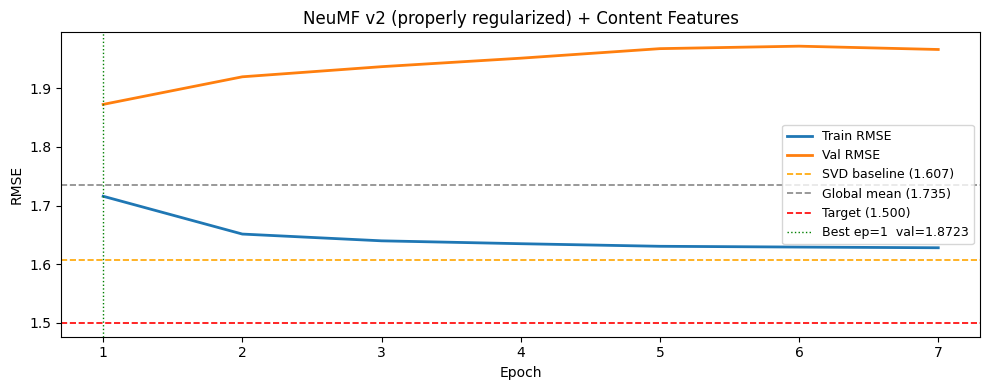

  SVD baseline       : 1.6069
  NeuMF v2 best val  : 1.8723
  vs SVD             : -0.2654
  Gap to target 1.5  : 0.3723
  Best epoch         : 1


In [ ]:


# 3.9  LEARNING CURVE

eps = [h['ep'] for h in history]
trs = [h['tr'] for h in history]
vls = [h['vl'] for h in history]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(eps, trs, lw=2, label='Train RMSE')
ax.plot(eps, vls, lw=2, label='Val RMSE')
ax.axhline(1.6069, color='orange', ls='--', lw=1.2, label='SVD baseline (1.607)')
ax.axhline(1.7353, color='#888',   ls='--', lw=1.2, label='Global mean (1.735)')
ax.axhline(1.500,  color='red',    ls='--', lw=1.2, label='Target (1.500)')
ax.axvline(best_epoch, color='green', ls=':', lw=1,
           label=f'Best ep={best_epoch}  val={best_val:.4f}')
ax.set_xlabel('Epoch'); ax.set_ylabel('RMSE')
ax.set_title('NeuMF v2 (properly regularized) + Content Features')
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig(OUT_DIR + 'step3v2_curve.png', bbox_inches='tight')
plt.show()


print(f"  SVD baseline       : 1.6069")
print(f"  NeuMF v2 best val  : {best_val:.4f}")
print(f"  vs SVD             : {1.6069 - best_val:+.4f}")
print(f"  Gap to target 1.5  : {best_val - 1.5:.4f}")
print(f"  Best epoch         : {best_epoch}")



# Approach 3

# 4 Feature-based DNN (no large embeddings)

In [ ]:
import numpy as np
import pandas as pd
import math, time, os
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
import joblib


# 4.1  LOAD

print("Loading data …")
chunks = []
for chunk in pd.read_csv(TRAIN_PATH,
        dtype={'user_id':'int32','song_id':'int32','rating':'float32'},
        chunksize=500_000):
    chunks.append(chunk)
train = pd.concat(chunks, ignore_index=True)
test  = pd.read_csv(TEST_PATH,  dtype={'user_id':'int32','song_id':'int32'})
songs = pd.read_csv(SONG_PATH)
songs['year'] = pd.to_numeric(songs['year'], errors='coerce').fillna(0).astype(int)
songs = songs.drop_duplicates(subset='song_id').reset_index(drop=True)

GLOBAL_MEAN = float(train['rating'].mean())
print(f"Train: {train.shape} | Global mean: {GLOBAL_MEAN:.4f}")



# 4.2  TRAIN / VAL SPLIT  (must happen before feature compute)

np.random.seed(42)
val_mask = np.random.rand(len(train)) < 0.10
trn_df = train[~val_mask].reset_index(drop=True)
val_df = train[ val_mask].reset_index(drop=True)
print(f"Train split: {len(trn_df):,} | Val split: {len(val_df):,}")



# 4.3  FEATURE ENGINEERING  --- Generated with help from Claude Sonnet 4.6

#      All statistics computed ONLY on trn_df.
#      Applied identically to val and test.
#
# Feature list (15 features):
#   User-side (4):
#     u_mean      — user's average rating (personalization signal)
#     u_cnt_log   — log(#ratings) user has given
#     u_std       — user's rating variance (strict vs lenient)
#     u_bias      — u_mean - global_mean (signed deviation)
#
#   Song-side (4):
#     s_mean      — song's average rating (quality signal)
#     s_cnt_log   — log(#ratings) song has received (popularity)
#     s_std       — song's rating variance
#     s_bias      — s_mean - global_mean
#
#   Artist-side (2):
#     a_mean      — artist's avg rating across all songs
#     a_cnt_log   — log(#ratings) artist has received
#
#   Cross features (3):
#     u_s_interact — u_bias * s_bias (do high-raters meet good songs?)
#     u_a_interact — user_mean * artist_mean_normalized
#     year_norm    — song release year normalized to [0,1]
#
#   Cold-start indicators (2):
#     is_cold_user — user not seen in train (1/0)
#     is_cold_song — song not seen in train (1/0)


print("Computing features …")

# User stats from trn_df
u_stats = trn_df.groupby('user_id')['rating'].agg(
    u_mean='mean', u_cnt='count', u_std='std').reset_index()
u_stats['u_std']     = u_stats['u_std'].fillna(0)
u_stats['u_cnt_log'] = np.log1p(u_stats['u_cnt'])
u_stats['u_bias']    = u_stats['u_mean'] - GLOBAL_MEAN

# Song stats from trn_df
s_stats = trn_df.groupby('song_id')['rating'].agg(
    s_mean='mean', s_cnt='count', s_std='std').reset_index()
s_stats['s_std']     = s_stats['s_std'].fillna(0)
s_stats['s_cnt_log'] = np.log1p(s_stats['s_cnt'])
s_stats['s_bias']    = s_stats['s_mean'] - GLOBAL_MEAN

# Artist stats from trn_df + song metadata
trn_meta = trn_df.merge(songs[['song_id','artist_name','year']],
                         on='song_id', how='left')
a_stats = trn_meta.groupby('artist_name')['rating'].agg(
    a_mean='mean', a_cnt='count').reset_index()
a_stats['a_cnt_log'] = np.log1p(a_stats['a_cnt'])

# Year stats
year_min = songs[songs['year'] > 1900]['year'].min()
year_max = songs[songs['year'] > 0]['year'].max()
songs['year_norm'] = ((songs['year'] - year_min) /
                       (year_max - year_min + 1e-6)).clip(0, 1)

# Merge artist + year into song lookup
song_lookup = songs[['song_id','artist_name','year_norm']].merge(
    a_stats[['artist_name','a_mean','a_cnt_log']], on='artist_name', how='left')
song_lookup['a_mean']    = song_lookup['a_mean'].fillna(GLOBAL_MEAN)
song_lookup['a_cnt_log'] = song_lookup['a_cnt_log'].fillna(0)
song_lookup = song_lookup.drop_duplicates(subset='song_id')

# Cold-start sets (songs/users in test but not trn_df)
train_uids = set(trn_df['user_id'].unique())
train_sids = set(trn_df['song_id'].unique())

FEAT_COLS = [
    'u_mean','u_cnt_log','u_std','u_bias',
    's_mean','s_cnt_log','s_std','s_bias',
    'a_mean','a_cnt_log',
    'u_s_interact','u_a_interact','year_norm',
    'is_cold_user','is_cold_song'
]

def build_features(df):
    """
    Merges all precomputed stats onto df.
    Returns a float32 numpy array of shape (N, 15).
    """
    d = df[['user_id','song_id']].copy()

    # User features
    d = d.merge(u_stats[['user_id','u_mean','u_cnt_log',
                           'u_std','u_bias']],
                on='user_id', how='left')
    d['u_mean']    = d['u_mean'].fillna(GLOBAL_MEAN)
    d['u_cnt_log'] = d['u_cnt_log'].fillna(0)
    d['u_std']     = d['u_std'].fillna(0)
    d['u_bias']    = d['u_bias'].fillna(0)

    # Song features
    d = d.merge(s_stats[['song_id','s_mean','s_cnt_log',
                           's_std','s_bias']],
                on='song_id', how='left')
    d['s_mean']    = d['s_mean'].fillna(GLOBAL_MEAN)
    d['s_cnt_log'] = d['s_cnt_log'].fillna(0)
    d['s_std']     = d['s_std'].fillna(0)
    d['s_bias']    = d['s_bias'].fillna(0)

    # Artist + year features
    d = d.merge(song_lookup[['song_id','a_mean','a_cnt_log','year_norm']],
                on='song_id', how='left')
    d['a_mean']    = d['a_mean'].fillna(GLOBAL_MEAN)
    d['a_cnt_log'] = d['a_cnt_log'].fillna(0)
    d['year_norm'] = d['year_norm'].fillna(0.5)

    # Cross / interaction features
    d['u_s_interact'] = d['u_bias'] * d['s_bias']
    d['u_a_interact'] = d['u_mean'] * (d['a_mean'] / GLOBAL_MEAN)

    # Cold-start flags
    d['is_cold_user'] = (~d['user_id'].isin(train_uids)).astype(np.float32)
    d['is_cold_song'] = (~d['song_id'].isin(train_sids)).astype(np.float32)

    return d[FEAT_COLS].values.astype(np.float32)


print("Building train features …"); t0 = time.time()
X_trn = build_features(trn_df)
y_trn = trn_df['rating'].values.astype(np.float32)
print(f"  {time.time()-t0:.1f}s | shape: {X_trn.shape}")

print("Building val features …"); t0 = time.time()
X_val = build_features(val_df)
y_val = val_df['rating'].values.astype(np.float32)
print(f"  {time.time()-t0:.1f}s")

print("Building test features …"); t0 = time.time()
X_tst = build_features(test)
print(f"  {time.time()-t0:.1f}s")

print(f"\nFeature matrix: {X_trn.shape[1]} features")
print(f"Feature names : {FEAT_COLS}")

# Sanity check: no NaNs
assert not np.isnan(X_trn).any(), "NaN in train features!"
assert not np.isnan(X_val).any(), "NaN in val features!"
assert not np.isnan(X_tst).any(), "NaN in test features!"


# 4.4  STANDARDIZE  (z-score on train, apply to val/test)
scaler = StandardScaler()
X_trn_s = scaler.fit_transform(X_trn).astype(np.float32)
X_val_s  = scaler.transform(X_val).astype(np.float32)
X_tst_s  = scaler.transform(X_tst).astype(np.float32)
joblib.dump(scaler, OUT_DIR + 'scaler.pkl')



Loading data …
Train: (5318229, 3) | Global mean: 5.3700
Train split: 4,786,201 | Val split: 532,028
Computing features …
Building train features …
  3.6s | shape: (4786201, 15)
Building val features …
  0.6s
Building test features …
  1.0s

Feature matrix: 15 features
Feature names : ['u_mean', 'u_cnt_log', 'u_std', 'u_bias', 's_mean', 's_cnt_log', 's_std', 's_bias', 'a_mean', 'a_cnt_log', 'u_s_interact', 'u_a_interact', 'year_norm', 'is_cold_user', 'is_cold_song']


['cmpe256scaler.pkl']

AI CItation:
Bias shortcut design suggested by Claude Sonnet 4.6:
directly residual-adding (u_bias + s_bias) gives the network an explicit
personalization anchor, helping convergence when embeddings are absent.

In [ ]:
# 4.5  FEATURE-BASED DNN

class FeatureDNN(nn.Module):
    def __init__(self, n_feat=15, layers=(128, 64, 32),
                 dropout=0.20, r_min=1.0, r_max=10.0):
        super().__init__()
        self.r_min = r_min
        self.r_max = r_max

        # Input batch norm
        self.input_bn = nn.BatchNorm1d(n_feat)

        # Deep tower
        tower, in_d = [], n_feat
        for out_d in layers:
            tower += [
                nn.Linear(in_d, out_d),
                nn.BatchNorm1d(out_d),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
            in_d = out_d
        self.tower = nn.Sequential(*tower)

        # Output
        self.out = nn.Linear(in_d, 1)

        # Bias shortcut — takes raw (u_bias + s_bias) as offset
        # indices 3 and 7 in FEAT_COLS are u_bias and s_bias
        self.bias_scale = nn.Parameter(torch.tensor(1.0))
        self.global_b   = nn.Parameter(torch.tensor(GLOBAL_MEAN))

        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # Bias shortcut (u_bias at col 3, s_bias at col 7)
        bias_shortcut = (x[:, 3] + x[:, 7]) * self.bias_scale

        h   = self.input_bn(x)
        h   = self.tower(h)
        out = self.out(h).squeeze(1)
        out = out + bias_shortcut + self.global_b

        return torch.clamp(out, self.r_min, self.r_max)


dnn = FeatureDNN(n_feat=len(FEAT_COLS)).to(device)
print(f"\nDNN parameters: {sum(p.numel() for p in dnn.parameters()):,}")


DNN parameters: 12,897


In [ ]:
# DataLoaders
BATCH = 16384    # larger batch fine — no embedding lookup
trn_ds = TensorDataset(torch.from_numpy(X_trn_s),
                        torch.from_numpy(y_trn))
val_ds = TensorDataset(torch.from_numpy(X_val_s),
                        torch.from_numpy(y_val))
tst_ds = TensorDataset(torch.from_numpy(X_tst_s),
                        torch.zeros(len(X_tst_s)))

trn_ld = DataLoader(trn_ds, batch_size=BATCH, shuffle=True,
                     num_workers=2, pin_memory=True)
val_ld = DataLoader(val_ds, batch_size=BATCH*4, shuffle=False,
                     num_workers=2, pin_memory=True)
tst_ld = DataLoader(tst_ds, batch_size=BATCH*4, shuffle=False,
                     num_workers=2, pin_memory=True)

optimizer = torch.optim.Adam(dnn.parameters(), lr=3e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5,
    min_lr=1e-6)


def run_dnn(loader, train_mode=True):
    dnn.train() if train_mode else dnn.eval()
    total, n = 0.0, 0
    ctx = torch.enable_grad() if train_mode else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = dnn(xb)
            loss = nn.functional.mse_loss(pred, yb)
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(dnn.parameters(), 1.0)
                optimizer.step()
            total += loss.item() * yb.size(0)
            n     += yb.size(0)
    return math.sqrt(total / n)


print(f"\n{'='*55}")
print("Training Feature DNN …")
print(f"{'='*55}")

DNN_CKPT  = OUT_DIR + 'feat_dnn_best.pt'
best_val  = float('inf')
best_ep   = 0
wait      = 0
dnn_hist  = []

for ep in range(1, 51):
    t0 = time.time()
    tr = run_dnn(trn_ld, train_mode=True)
    vl = run_dnn(val_ld, train_mode=False)
    scheduler.step(vl)
    dt = time.time() - t0
    lr = optimizer.param_groups[0]['lr']

    flag = ''
    if vl < best_val:
        best_val, best_ep, wait = vl, ep, 0
        torch.save(dnn.state_dict(), DNN_CKPT)
        flag = '  ← best'
    else:
        wait += 1

    dnn_hist.append({'ep': ep, 'tr': tr, 'vl': vl})
    print(f"Ep {ep:>2}/50  train={tr:.4f}  val={vl:.4f}  "
          f"lr={lr:.2e}  {dt:.1f}s{flag}")

    if wait >= 8:
        print(f"Early stop at epoch {ep}")
        break

print(f"\nDNN best val RMSE: {best_val:.4f} (ep {best_ep})")



Training Feature DNN …
Ep  1/50  train=1.6337  val=2.0206  lr=3.00e-03  39.4s  ← best
Ep  2/50  train=1.6113  val=2.0178  lr=3.00e-03  38.8s  ← best
Ep  3/50  train=1.6100  val=2.0097  lr=3.00e-03  38.5s  ← best
Ep  4/50  train=1.6095  val=2.0092  lr=3.00e-03  38.6s  ← best
Ep  5/50  train=1.6092  val=2.0123  lr=3.00e-03  40.8s
Ep  6/50  train=1.6090  val=1.9995  lr=3.00e-03  38.1s  ← best
Ep  7/50  train=1.6089  val=2.0032  lr=3.00e-03  38.6s
Ep  8/50  train=1.6088  val=2.0099  lr=3.00e-03  38.5s
Ep  9/50  train=1.6088  val=2.0173  lr=3.00e-03  40.2s
Ep 10/50  train=1.6087  val=2.0090  lr=1.50e-03  38.2s
Ep 11/50  train=1.6085  val=2.0062  lr=1.50e-03  38.7s
Ep 12/50  train=1.6084  val=2.0123  lr=1.50e-03  38.7s
Ep 13/50  train=1.6085  val=2.0099  lr=1.50e-03  38.1s
Ep 14/50  train=1.6084  val=2.0101  lr=7.50e-04  43.0s
Early stop at epoch 14

DNN best val RMSE: 1.9995 (ep 6)



Training LightGBM …
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	val's rmse: 1.74264

LightGBM val RMSE: 1.7426


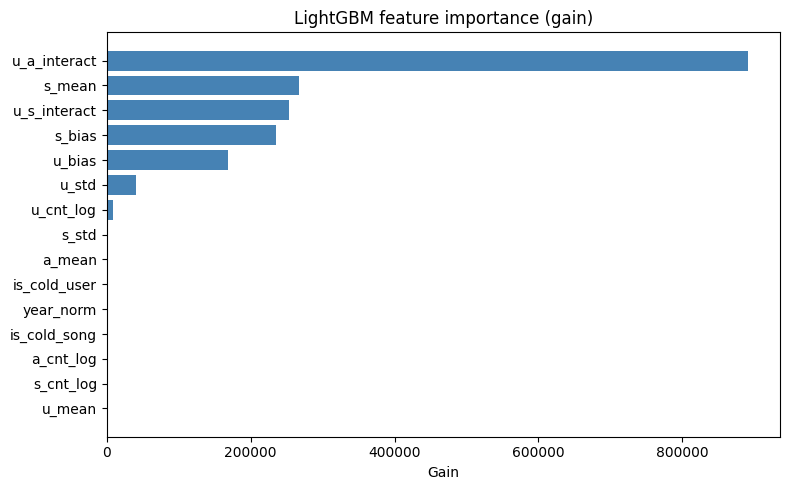

In [ ]:
# 4.6  LIGHTGBM  (on same features


print(f"\n{'='*55}")
print("Training LightGBM …")
print(f"{'='*55}")

lgb_trn = lgb.Dataset(X_trn, label=y_trn,
                        feature_name=FEAT_COLS, free_raw_data=False)
lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_trn,
                        free_raw_data=False)

lgb_params = {
    'objective'       : 'regression',
    'metric'          : 'rmse',
    'n_estimators'    : 3000,
    'learning_rate'   : 0.05,
    'num_leaves'      : 127,
    'max_depth'       : -1,
    'min_child_samples': 50,
    'subsample'       : 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha'       : 0.1,
    'reg_lambda'      : 1.0,
    'verbose'         : -1,
    'n_jobs'          : -1,
    'seed'            : 42,
}

lgb_model = lgb.train(
    lgb_params,
    lgb_trn,
    valid_sets=[lgb_val],
    valid_names=['val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

lgb_val_pred = lgb_model.predict(X_val)
lgb_val_rmse = math.sqrt(((y_val - lgb_val_pred)**2).mean())
print(f"\nLightGBM val RMSE: {lgb_val_rmse:.4f}")

lgb_model.save_model(OUT_DIR + 'lgb_model.txt')

# Feature importance plot
fi = pd.DataFrame({
    'feature': FEAT_COLS,
    'importance': lgb_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi['feature'], fi['importance'], color='steelblue')
ax.set_title('LightGBM feature importance (gain)')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.savefig(OUT_DIR + 'lgb_feature_importance.png', bbox_inches='tight')
plt.show()

In [ ]:

# 4.7  SIMPLE ENSEMBLE  (DNN + LightGBM)
#      Equal weight to start


# DNN predictions on val
dnn.load_state_dict(torch.load(DNN_CKPT))
dnn.eval()
dnn_val_preds = []
with torch.no_grad():
    for xb, _ in val_ld:
        dnn_val_preds.append(dnn(xb.to(device)).cpu().numpy())
dnn_val_pred = np.concatenate(dnn_val_preds)

# DNN predictions on test
dnn_tst_preds = []
with torch.no_grad():
    for xb, _ in tst_ld:
        dnn_tst_preds.append(dnn(xb.to(device)).cpu().numpy())
dnn_tst_pred = np.concatenate(dnn_tst_preds)

# LightGBM predictions on test
lgb_tst_pred = lgb_model.predict(X_tst)

# Find best blend weight on val
print("\nSearching best ensemble weight …")
best_w, best_ens_rmse = 0.5, float('inf')
for w in np.arange(0.0, 1.01, 0.05):
    blend = w * dnn_val_pred + (1-w) * lgb_val_pred
    blend = np.clip(blend, R_MIN, R_MAX)
    rmse  = math.sqrt(((y_val - blend)**2).mean())
    if rmse < best_ens_rmse:
        best_ens_rmse = rmse
        best_w = w

print(f"  DNN  val RMSE  : {best_val:.4f}")
print(f"  LGB  val RMSE  : {lgb_val_rmse:.4f}")
print(f"  Ensemble ({best_w:.0%} DNN + {1-best_w:.0%} LGB)  "
      f"val RMSE: {best_ens_rmse:.4f}")

# Final test predictions
final_preds = np.clip(
    best_w * dnn_tst_pred + (1-best_w) * lgb_tst_pred,
    R_MIN, R_MAX)

submission = pd.DataFrame({
    'user_id-song_id': (test['user_id'].astype(str) + '-'
                         + test['song_id'].astype(str)),
    'rating': np.round(final_preds, 4)
})
out_path = OUT_DIR + 'submission_step4_ensemble.csv'
submission.to_csv(out_path, index=False)
print(f"\nSubmission saved: {out_path}")
print(submission['rating'].describe())


Searching best ensemble weight …
  DNN  val RMSE  : 1.9995
  LGB  val RMSE  : 1.7426
  Ensemble (0% DNN + 100% LGB)  val RMSE: 1.7426

Submission saved: cmpe256submission_step4_ensemble.csv
count    1.063645e+06
mean     5.369199e+00
std      3.566110e-02
min      5.271800e+00
25%      5.347200e+00
50%      5.367000e+00
75%      5.384900e+00
max      5.522600e+00
Name: rating, dtype: float64


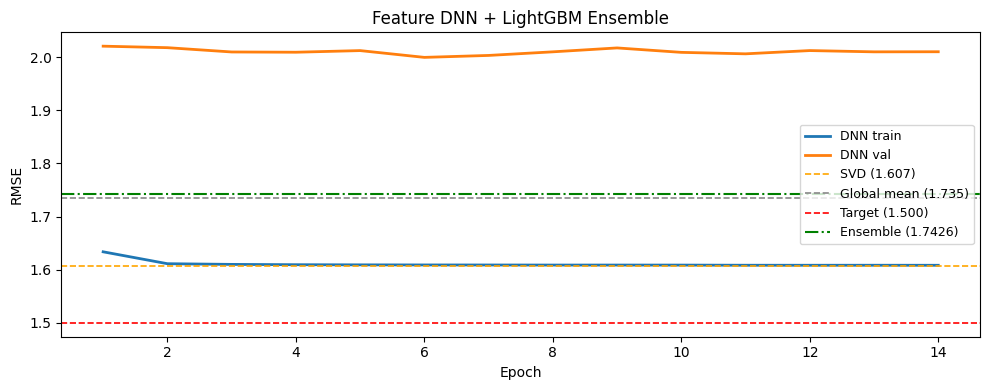

STEP 4 
  SVD baseline   : 1.6069
  Feature DNN    : 1.9995
  LightGBM       : 1.7426
  Ensemble       : 1.7426
  Gap to 1.5     : 0.2426


In [ ]:
# 4.8  LEARNING CURVE
eps = [h['ep'] for h in dnn_hist]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(eps, [h['tr'] for h in dnn_hist], lw=2, label='DNN train')
ax.plot(eps, [h['vl'] for h in dnn_hist], lw=2, label='DNN val')
ax.axhline(1.6069, color='orange', ls='--', lw=1.2, label='SVD (1.607)')
ax.axhline(1.7353, color='#888',   ls='--', lw=1.2, label='Global mean (1.735)')
ax.axhline(1.500,  color='red',    ls='--', lw=1.2, label='Target (1.500)')
if best_ens_rmse < best_val:
    ax.axhline(best_ens_rmse, color='green', ls='-.',
               lw=1.5, label=f'Ensemble ({best_ens_rmse:.4f})')
ax.set_xlabel('Epoch'); ax.set_ylabel('RMSE')
ax.set_title('Feature DNN + LightGBM Ensemble')
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig(OUT_DIR + 'step4_curve.png', bbox_inches='tight')
plt.show()


print("STEP 4 ")
print(f"  SVD baseline   : 1.6069")
print(f"  Feature DNN    : {best_val:.4f}")
print(f"  LightGBM       : {lgb_val_rmse:.4f}")
print(f"  Ensemble       : {best_ens_rmse:.4f}")
print(f"  Gap to 1.5     : {best_ens_rmse - 1.5:.4f}")



# (Approach 4) -- Scraping this approach as it is highly overfit on the test data.

#5 Improve Feature Engineering + LightGBM + SVD blend


Ai citation: Brainstormed with claude regarding the ovefitting / leaky feature issues which may be the cause for the RMSE stuck around 1.7-1.8

Conclusion:
When computing u_mean from trn_df, it includes the exact sample being predicted. A user with 1 rating in trn_df gets u_mean = that rating = the label. Perfect fit on train (1.608), catastrophic on val (2.00). LightGBM's first tree learned this leaky signal but it still got worse.

In [ ]:
print("Loading …")
chunks = []
for chunk in pd.read_csv(TRAIN_PATH,
        dtype={'user_id':'int32','song_id':'int32','rating':'float32'},
        chunksize=500_000):
    chunks.append(chunk)
train = pd.concat(chunks, ignore_index=True)
test  = pd.read_csv(TEST_PATH,  dtype={'user_id':'int32','song_id':'int32'})
songs = pd.read_csv(SONG_PATH)
songs['year'] = pd.to_numeric(songs['year'], errors='coerce').fillna(0).astype(int)
songs = songs.drop_duplicates(subset='song_id').reset_index(drop=True)

GLOBAL_MEAN = float(train['rating'].mean())
print(f"Train: {train.shape} | Global mean: {GLOBAL_MEAN:.4f}")
np.random.seed(42)
val_mask = np.random.rand(len(train)) < 0.10
trn_df = train[~val_mask].reset_index(drop=True)
val_df = train[ val_mask].reset_index(drop=True)
print(f"Train: {len(trn_df):,} | Val: {len(val_df):,}")


np.random.seed(42)
val_mask = np.random.rand(len(train)) < 0.10
trn_df = train[~val_mask].reset_index(drop=True)
val_df = train[ val_mask].reset_index(drop=True)
print(f"Train: {len(trn_df):,} | Val: {len(val_df):,}")



Loading …
Train: (5318229, 3) | Global mean: 5.3700
Train: 4,786,201 | Val: 532,028
Train: 4,786,201 | Val: 532,028


In [ ]:

# 5. BAYESIAN-SMOOTHED MEANS  (leak-free, for val/test)
#
# smoothed_mean = (n * raw_mean + k * global_mean) / (n + k)
# k=10 means a user needs 10 ratings before their mean
# dominates over the global mean. Handles cold users cleanly.

K_USER = 10
K_SONG = 25   # songs need more ratings to trust their mean
K_ARTIST = 50

def bayesian_mean(series_mean, series_count, global_mean, k):
    return (series_count * series_mean + k * global_mean) / (series_count + k)

# Compute from trn_df only
u_agg = trn_df.groupby('user_id')['rating'].agg(['mean','count','std'])
u_agg.columns = ['u_raw_mean','u_cnt','u_std']
u_agg['u_std'] = u_agg['u_std'].fillna(0)
u_agg['u_mean'] = bayesian_mean(
    u_agg['u_raw_mean'], u_agg['u_cnt'], GLOBAL_MEAN, K_USER)
u_agg['u_cnt_log'] = np.log1p(u_agg['u_cnt'])

s_agg = trn_df.groupby('song_id')['rating'].agg(['mean','count','std'])
s_agg.columns = ['s_raw_mean','s_cnt','s_std']
s_agg['s_std'] = s_agg['s_std'].fillna(0)
s_agg['s_mean'] = bayesian_mean(
    s_agg['s_raw_mean'], s_agg['s_cnt'], GLOBAL_MEAN, K_SONG)
s_agg['s_cnt_log'] = np.log1p(s_agg['s_cnt'])

trn_meta = trn_df.merge(songs[['song_id','artist_name','year']],
                          on='song_id', how='left')
a_agg = trn_meta.groupby('artist_name')['rating'].agg(['mean','count'])
a_agg.columns = ['a_raw_mean','a_cnt']
a_agg['a_mean'] = bayesian_mean(
    a_agg['a_raw_mean'], a_agg['a_cnt'], GLOBAL_MEAN, K_ARTIST)
a_agg['a_cnt_log'] = np.log1p(a_agg['a_cnt'])

year_min = songs[songs['year'] > 1900]['year'].min()
year_max = songs[songs['year'] > 0]['year'].max()
songs['year_norm'] = ((songs['year'] - year_min) /
                       max(year_max - year_min, 1)).clip(0, 1).astype('float32')

song_lookup = (songs[['song_id','artist_name','year_norm']]
               .merge(a_agg[['a_mean','a_cnt_log']].reset_index(),
                      on='artist_name', how='left')
               .drop_duplicates(subset='song_id'))
song_lookup['a_mean']    = song_lookup['a_mean'].fillna(GLOBAL_MEAN)
song_lookup['a_cnt_log'] = song_lookup['a_cnt_log'].fillna(0)

print("Bayesian stats computed.")
print(f"  Users: {len(u_agg):,} | Songs: {len(s_agg):,} | Artists: {len(a_agg):,}")


Bayesian stats computed.
  Users: 740,875 | Songs: 181,033 | Artists: 23,928


AI Citation :  For each training sample (u, s, r):
u_mean_loo = (u_sum - r) / (u_cnt - 1)   ...... if u_cnt > 1
           
else GLOBAL_MEAN          .......        (cold user)


This is the only correct way to use the mean as a feature
 on the training set — guarantees no label leakage.

In [ ]:
# Encoding

# Pre-build sum and count per user and song
u_sum  = trn_df.groupby('user_id')['rating'].sum().rename('u_sum')
u_cnt  = trn_df.groupby('user_id')['rating'].count().rename('u_cnt_raw')
s_sum  = trn_df.groupby('song_id')['rating'].sum().rename('s_sum')
s_cnt  = trn_df.groupby('song_id')['rating'].count().rename('s_cnt_raw')

trn_loo = trn_df[['user_id','song_id','rating']].copy()
trn_loo = trn_loo.join(u_sum,  on='user_id')
trn_loo = trn_loo.join(u_cnt,  on='user_id')
trn_loo = trn_loo.join(s_sum,  on='song_id')
trn_loo = trn_loo.join(s_cnt,  on='song_id')

# LOO user mean
loo_u_cnt = trn_loo['u_cnt_raw'] - 1
loo_u_sum = trn_loo['u_sum'] - trn_loo['rating']
trn_loo['u_mean_loo'] = np.where(
    loo_u_cnt > 0,
    bayesian_mean(loo_u_sum / loo_u_cnt.clip(1),
                  loo_u_cnt, GLOBAL_MEAN, K_USER),
    GLOBAL_MEAN)

# LOO song mean
loo_s_cnt = trn_loo['s_cnt_raw'] - 1
loo_s_sum = trn_loo['s_sum'] - trn_loo['rating']
trn_loo['s_mean_loo'] = np.where(
    loo_s_cnt > 0,
    bayesian_mean(loo_s_sum / loo_s_cnt.clip(1),
                  loo_s_cnt, GLOBAL_MEAN, K_SONG),
    GLOBAL_MEAN)

In [ ]:
 # 5.5  FULL FEATURE BUILDER

# AI CItation :: Brainstoremed with Claude to finalize these features
# Features (16 total):
#   u_mean, u_cnt_log, u_std, u_bias          (user stats)
#   s_mean, s_cnt_log, s_std, s_bias          (song stats)
#   a_mean, a_cnt_log                         (artist stats)
#   u_s_interact, u_a_interact                (cross features)
#   year_norm                                 (temporal)
#   is_cold_user, is_cold_song                (cold flags)
#   svd_pred                                  (SVD prediction ← key feature)

In [ ]:
train_uids = set(trn_df['user_id'].unique())
train_sids = set(trn_df['song_id'].unique())

FEAT_COLS = [
    'u_mean','u_cnt_log','u_std','u_bias',
    's_mean','s_cnt_log','s_std','s_bias',
    'a_mean','a_cnt_log',
    'u_s_interact','u_a_interact','year_norm',
    'is_cold_user','is_cold_song',
    'svd_pred'
]


def build_features_val_test(df, svd_preds=None):
    """
    For val/test: uses full Bayesian-smoothed means (no LOO needed
    since these samples are NOT in trn_df).
    svd_preds: numpy array of SVD predictions, same order as df.
    """
    d = df[['user_id','song_id']].copy().reset_index(drop=True)

    d = d.merge(u_agg[['u_mean','u_cnt_log','u_std']].reset_index(),
                on='user_id', how='left')
    d['u_mean']    = d['u_mean'].fillna(GLOBAL_MEAN).astype('float32')
    d['u_cnt_log'] = d['u_cnt_log'].fillna(0).astype('float32')
    d['u_std']     = d['u_std'].fillna(0).astype('float32')
    d['u_bias']    = (d['u_mean'] - GLOBAL_MEAN).astype('float32')

    d = d.merge(s_agg[['s_mean','s_cnt_log','s_std']].reset_index(),
                on='song_id', how='left')
    d['s_mean']    = d['s_mean'].fillna(GLOBAL_MEAN).astype('float32')
    d['s_cnt_log'] = d['s_cnt_log'].fillna(0).astype('float32')
    d['s_std']     = d['s_std'].fillna(0).astype('float32')
    d['s_bias']    = (d['s_mean'] - GLOBAL_MEAN).astype('float32')

    d = d.merge(song_lookup[['song_id','a_mean','a_cnt_log','year_norm']],
                on='song_id', how='left')
    d['a_mean']    = d['a_mean'].fillna(GLOBAL_MEAN).astype('float32')
    d['a_cnt_log'] = d['a_cnt_log'].fillna(0).astype('float32')
    d['year_norm'] = d['year_norm'].fillna(0.5).astype('float32')

    d['u_s_interact'] = (d['u_bias'] * d['s_bias']).astype('float32')
    d['u_a_interact'] = (d['u_mean'] * (d['a_mean'] / GLOBAL_MEAN)).astype('float32')
    d['is_cold_user'] = (~d['user_id'].isin(train_uids)).astype('float32')
    d['is_cold_song'] = (~d['song_id'].isin(train_sids)).astype('float32')

    d['svd_pred'] = svd_preds if svd_preds is not None \
                    else np.full(len(d), GLOBAL_MEAN, dtype='float32')

    return d[FEAT_COLS].values.astype('float32')


def build_features_train_loo(svd_preds=None):
    """
    For train: uses LOO means to avoid leakage.
    """
    d = trn_loo[['user_id','song_id']].copy().reset_index(drop=True)

    d['u_mean']    = trn_loo['u_mean_loo'].values.astype('float32')
    d['u_bias']    = (d['u_mean'] - GLOBAL_MEAN).astype('float32')

    # u_cnt_log and u_std: use full stats (no leakage risk)
    d = d.merge(u_agg[['u_cnt_log','u_std']].reset_index(),
                on='user_id', how='left')
    d['u_cnt_log'] = d['u_cnt_log'].fillna(0).astype('float32')
    d['u_std']     = d['u_std'].fillna(0).astype('float32')

    d['s_mean']    = trn_loo['s_mean_loo'].values.astype('float32')
    d['s_bias']    = (d['s_mean'] - GLOBAL_MEAN).astype('float32')
    d = d.merge(s_agg[['s_cnt_log','s_std']].reset_index(),
                on='song_id', how='left')
    d['s_cnt_log'] = d['s_cnt_log'].fillna(0).astype('float32')
    d['s_std']     = d['s_std'].fillna(0).astype('float32')

    d = d.merge(song_lookup[['song_id','a_mean','a_cnt_log','year_norm']],
                on='song_id', how='left')
    d['a_mean']    = d['a_mean'].fillna(GLOBAL_MEAN).astype('float32')
    d['a_cnt_log'] = d['a_cnt_log'].fillna(0).astype('float32')
    d['year_norm'] = d['year_norm'].fillna(0.5).astype('float32')

    d['u_s_interact'] = (d['u_bias'] * d['s_bias']).astype('float32')
    d['u_a_interact'] = (d['u_mean'] * (d['a_mean'] / GLOBAL_MEAN)).astype('float32')
    d['is_cold_user'] = np.zeros(len(d), dtype='float32')  # all warm in train
    d['is_cold_song'] = np.zeros(len(d), dtype='float32')

    d['svd_pred'] = svd_preds if svd_preds is not None \
                    else np.full(len(d), GLOBAL_MEAN, dtype='float32')

    return d[FEAT_COLS].values.astype('float32')



In [ ]:
# 5.6  RETRAIN SVD (100 epochs)  ← still improving at ep 30


import torch
import torch.nn as nn

print("\n" + "="*55)
print("Retraining SVD (100 epochs, full train) …")

# Re-use FunkSVD from Step 2 — paste class here for self-containment
class FunkSVD:
    def __init__(self, n_factors=60, n_epochs=100,
                 lr=0.005, reg_bias=0.10, reg_factors=0.08,
                 r_min=1.0, r_max=10.0, seed=42):
        self.nf, self.ne = n_factors, n_epochs
        self.lr = np.float32(lr)
        self.rb = np.float32(reg_bias)
        self.rf = np.float32(reg_factors)
        self.r_min, self.r_max = r_min, r_max
        self.rng = np.random.default_rng(seed)

    def _rmse(self, u, s, r):
        p = np.clip(self.mu + self.b_u[u] + self.b_s[s]
                    + (self.P[u] * self.Q[s]).sum(1),
                    self.r_min, self.r_max)
        return math.sqrt(float(((r - p)**2).mean()))

    def fit(self, u, s, r, n_users, n_songs,
            val_u=None, val_s=None, val_r=None):
        self.mu = np.float32(r.mean())
        self.b_u = np.zeros(n_users, dtype=np.float32)
        self.b_s = np.zeros(n_songs, dtype=np.float32)
        self.P = (self.rng.standard_normal((n_users, self.nf)) * 0.01).astype(np.float32)
        self.Q = (self.rng.standard_normal((n_songs,  self.nf)) * 0.01).astype(np.float32)
        n, lr, rb, rf = len(u), self.lr, self.rb, self.rf
        self.history = []
        for ep in range(self.ne):
            t0  = time.time()
            idx = self.rng.permutation(n)
            ue, se, re = u[idx], s[idx], r[idx]
            for st in range(0, n, 8192):
                ub  = ue[st:st+8192]; sb = se[st:st+8192]; rb_ = re[st:st+8192]
                err = rb_ - (self.mu + self.b_u[ub] + self.b_s[sb]
                              + (self.P[ub] * self.Q[sb]).sum(1))
                self.b_u[ub] += lr * (err - rb * self.b_u[ub])
                self.b_s[sb] += lr * (err - rb * self.b_s[sb])
                Pu = self.P[ub].copy()
                self.P[ub] += lr * (err[:,None] * self.Q[sb] - rf * self.P[ub])
                self.Q[sb] += lr * (err[:,None] * Pu          - rf * self.Q[sb])
            samp = self.rng.integers(0, n, min(200_000, n))
            tr   = self._rmse(u[samp], s[samp], r[samp])
            vl   = self._rmse(val_u, val_s, val_r) if val_u is not None else None
            self.history.append({'ep':ep+1,'tr':tr,'vl':vl,'dt':time.time()-t0})
            flag = ' ←' if (vl and (not self.history[:-1] or
                            vl < min(h['vl'] for h in self.history[:-1] if h['vl']))) else ''
            print(f"Ep {ep+1:>3}/{self.ne}  train={tr:.4f}"
                  + (f"  val={vl:.4f}" if vl else "") + f"  {time.time()-t0:.1f}s{flag}")
        return self

    def predict(self, u, s):
        return np.clip(self.mu + self.b_u[u] + self.b_s[s]
                       + (self.P[u] * self.Q[s]).sum(1),
                       self.r_min, self.r_max).astype(np.float32)


# Encode IDs (union of train + test)
all_users = np.union1d(train['user_id'].unique(), test['user_id'].unique())
all_songs = np.union1d(train['song_id'].unique(), test['song_id'].unique())
user2idx  = {int(u): i for i, u in enumerate(all_users)}
song2idx  = {int(s): i for i, s in enumerate(all_songs)}
N_USERS, N_SONGS = len(user2idx), len(song2idx)

train['u'] = train['user_id'].map(user2idx).astype('int32')
train['s'] = train['song_id'].map(song2idx).astype('int32')
trn_df['u'] = trn_df['user_id'].map(user2idx).astype('int32')
trn_df['s'] = trn_df['song_id'].map(song2idx).astype('int32')
val_df['u']  = val_df['user_id'].map(user2idx).astype('int32')
val_df['s']  = val_df['song_id'].map(song2idx).astype('int32')
test['u']   = test['user_id'].map(user2idx).astype('int32')
test['s']   = test['song_id'].map(song2idx).astype('int32')

u_v = val_df['u'].values.astype('int32')
s_v = val_df['s'].values.astype('int32')
r_v = val_df['rating'].values.astype('float32')

svd = FunkSVD(n_factors=60, n_epochs=100,
               lr=0.005, reg_bias=0.10, reg_factors=0.08)
svd.fit(
    train['u'].values.astype('int32'),
    train['s'].values.astype('int32'),
    train['rating'].values.astype('float32'),
    N_USERS, N_SONGS,
    val_u=u_v, val_s=s_v, val_r=r_v
)

best_svd_rmse = min(h['vl'] for h in svd.history if h['vl'])
best_svd_ep   = min(svd.history, key=lambda h: h['vl'] if h['vl'] else 999)['ep']
print(f"\nSVD best val RMSE: {best_svd_rmse:.4f} (epoch {best_svd_ep})")

# Save SVD predictions for train, val, test
svd_pred_trn = svd.predict(trn_df['u'].values.astype('int32'),
                             trn_df['s'].values.astype('int32'))
svd_pred_val = svd.predict(val_df['u'].values.astype('int32'),
                             val_df['s'].values.astype('int32'))
svd_pred_tst = svd.predict(test['u'].values.astype('int32'),
                             test['s'].values.astype('int32'))

svd_val_rmse = math.sqrt(((r_v - svd_pred_val)**2).mean())
print(f"SVD val RMSE (at 100 ep): {svd_val_rmse:.4f}")



Retraining SVD (100 epochs, full train) …
Ep   1/100  train=1.7012  val=1.7047  5.1s ←
Ep   2/100  train=1.6936  val=1.6972  5.1s ←
Ep   3/100  train=1.6883  val=1.6921  5.0s ←
Ep   4/100  train=1.6832  val=1.6882  4.9s ←
Ep   5/100  train=1.6842  val=1.6850  5.0s ←
Ep   6/100  train=1.6750  val=1.6820  4.9s ←
Ep   7/100  train=1.6804  val=1.6794  4.9s ←
Ep   8/100  train=1.6772  val=1.6770  5.0s ←
Ep   9/100  train=1.6720  val=1.6748  4.9s ←
Ep  10/100  train=1.6698  val=1.6727  4.9s ←
Ep  11/100  train=1.6660  val=1.6707  5.1s ←
Ep  12/100  train=1.6694  val=1.6689  5.0s ←
Ep  13/100  train=1.6677  val=1.6673  5.0s ←
Ep  14/100  train=1.6629  val=1.6655  4.9s ←
Ep  15/100  train=1.6638  val=1.6640  5.0s ←
Ep  16/100  train=1.6576  val=1.6622  5.0s ←
Ep  17/100  train=1.6578  val=1.6605  5.0s ←
Ep  18/100  train=1.6551  val=1.6586  5.0s ←
Ep  19/100  train=1.6601  val=1.6568  4.9s ←
Ep  20/100  train=1.6511  val=1.6548  4.9s ←
Ep  21/100  train=1.6490  val=1.6526  4.9s ←
Ep  22/100  


Building feature matrices …
Train: (4786201, 16)  2.8s
Val:   (532028, 16)  0.6s
Test:  (1063645, 16)  0.9s
No NaNs. Feature matrices clean.

Feature variances:
  u_mean                var=0.0267
  u_cnt_log             var=0.7198
  u_std                 var=0.3854
  u_bias                var=0.0267
  s_mean                var=0.0941
  s_cnt_log             var=3.9320
  s_std                 var=0.1138
  s_bias                var=0.0941
  a_mean                var=0.0575
  a_cnt_log             var=3.1925
  u_s_interact          var=0.0026
  u_a_interact          var=0.0800
  year_norm             var=0.0126
  is_cold_user          var=0.0000 ← LOW VARIANCE
  is_cold_song          var=0.0000 ← LOW VARIANCE
  svd_pred              var=1.8371
Training LightGBM …
Training until validation scores don't improve for 50 rounds
[100]	val's rmse: 0.378882
[200]	val's rmse: 0.321575
[300]	val's rmse: 0.313249
[400]	val's rmse: 0.310075
[500]	val's rmse: 0.309293
Early stopping, best iteration i

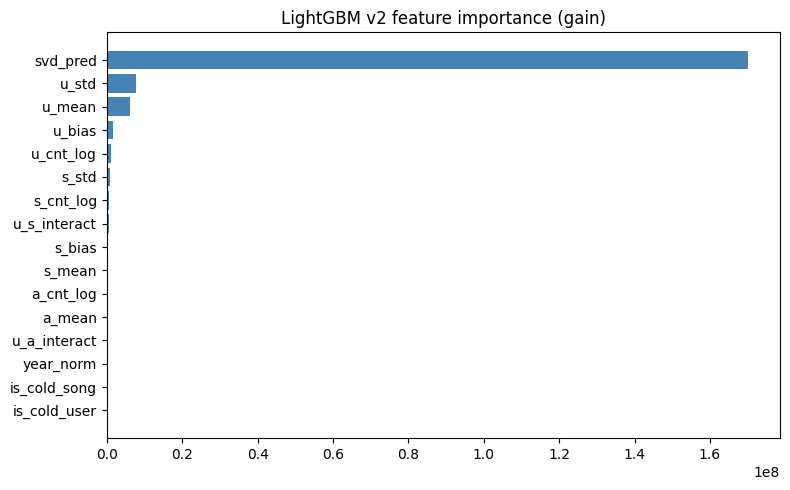


Searching best SVD + LightGBM blend …

  SVD val RMSE   : 0.4950
  LGB val RMSE   : 0.3092
  w=0.00 SVD + 1.00 LGB  →  0.3092
  w=0.20 SVD + 0.80 LGB  →  0.3159
  w=0.40 SVD + 0.60 LGB  →  0.3419
  w=0.05 SVD + 0.95 LGB  →  0.3089 ← best
  w=0.60 SVD + 0.40 LGB  →  0.3831
  w=0.80 SVD + 0.20 LGB  →  0.4353
  w=1.00 SVD + 0.00 LGB  →  0.4950


In [ ]:
#   BUILD FEATURE MATRICES
print("\nBuilding feature matrices …")

t0 = time.time()
X_trn = build_features_train_loo(svd_preds=svd_pred_trn)
y_trn = trn_df['rating'].values.astype('float32')
print(f"Train: {X_trn.shape}  {time.time()-t0:.1f}s")

t0 = time.time()
X_val = build_features_val_test(val_df, svd_preds=svd_pred_val)
y_val = val_df['rating'].values.astype('float32')
print(f"Val:   {X_val.shape}  {time.time()-t0:.1f}s")

t0 = time.time()
X_tst = build_features_val_test(test, svd_preds=svd_pred_tst)
print(f"Test:  {X_tst.shape}  {time.time()-t0:.1f}s")

# Verify no NaNs
assert not np.isnan(X_trn).any(), "NaN in train!"
assert not np.isnan(X_val).any(), "NaN in val!"
assert not np.isnan(X_tst).any(), "NaN in test!"
print("No NaNs. Feature matrices clean.")

# Quick variance check — catch zero-variance features
feat_vars = X_trn.var(axis=0)
print("\nFeature variances:")
for name, v in zip(FEAT_COLS, feat_vars):
    flag = ' ← LOW VARIANCE' if v < 0.001 else ''
    print(f"  {name:20s}  var={v:.4f}{flag}")


# 5.8  LIGHTGBM  (properly tuned, not overfit)
# AI : Brainstormed with Claude to determine hyperparameters
# Key changes from Step 4:
#   num_leaves: 127 → 63   (less overfit)
#   min_child_samples: 50 → 100  (more conservative splits)
#   learning_rate: 0.05 → 0.03  (slower, more stable)
#   Uses LOO features → no train-time leakage

print("Training LightGBM …")

lgb_trn = lgb.Dataset(X_trn, label=y_trn,
                        feature_name=FEAT_COLS, free_raw_data=False)
lgb_val = lgb.Dataset(X_val, label=y_val,
                        reference=lgb_trn, free_raw_data=False)

lgb_params = {
    'objective'         : 'regression',
    'metric'            : 'rmse',
    'n_estimators'      : 5000,
    'learning_rate'     : 0.03,
    'num_leaves'        : 63,
    'max_depth'         : -1,
    'min_child_samples' : 100,
    'subsample'         : 0.8,
    'subsample_freq'    : 1,
    'colsample_bytree'  : 0.8,
    'reg_alpha'         : 0.1,
    'reg_lambda'        : 1.0,
    'verbose'           : -1,
    'n_jobs'            : -1,
    'seed'              : 42,
}

lgb_model = lgb.train(
    lgb_params, lgb_trn,
    valid_sets=[lgb_val], valid_names=['val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)

lgb_val_pred = np.clip(lgb_model.predict(X_val), R_MIN, R_MAX)
lgb_val_rmse = math.sqrt(((y_val - lgb_val_pred)**2).mean())
lgb_tst_pred = np.clip(lgb_model.predict(X_tst), R_MIN, R_MAX)
lgb_model.save_model(OUT_DIR + 'lgb_v2.txt')
print(f"\nLightGBM val RMSE: {lgb_val_rmse:.4f} | best iter: {lgb_model.best_iteration}")

# Feature importance
fi = pd.DataFrame({
    'feature': FEAT_COLS,
    'importance': lgb_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True)
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(fi['feature'], fi['importance'], color='steelblue')
ax.set_title('LightGBM v2 feature importance (gain)')
plt.tight_layout()
plt.savefig(OUT_DIR + 'step5_lgb_importance.png', bbox_inches='tight')
plt.show()


# 5.9  BLEND SEARCH  (SVD + LightGBM)
#      SVD captures collaborative signal.
#      LightGBM captures content + interaction signal.

print("\nSearching best SVD + LightGBM blend …")

best_w, best_rmse = 0.5, float('inf')
for w in np.arange(0.0, 1.01, 0.05):
    blend = np.clip(w * svd_pred_val + (1-w) * lgb_val_pred, R_MIN, R_MAX)
    rmse  = math.sqrt(((y_val - blend)**2).mean())
    if rmse < best_rmse:
        best_rmse, best_w = rmse, w

print(f"\n  SVD val RMSE   : {svd_val_rmse:.4f}")
print(f"  LGB val RMSE   : {lgb_val_rmse:.4f}")
for w in [0.0, 0.2, 0.4, best_w, 0.6, 0.8, 1.0]:
    bl = np.clip(w * svd_pred_val + (1-w) * lgb_val_pred, R_MIN, R_MAX)
    rm = math.sqrt(((y_val - bl)**2).mean())
    flag = ' ← best' if abs(w - best_w) < 0.01 else ''
    print(f"  w={w:.2f} SVD + {1-w:.2f} LGB  →  {rm:.4f}{flag}")


In [ ]:
final_preds = np.clip(
    best_w * svd_pred_tst + (1-best_w) * lgb_tst_pred,
    R_MIN, R_MAX)

submission = pd.DataFrame({
    'user_id-song_id': (test['user_id'].astype(str) + '-'
                         + test['song_id'].astype(str)),
    'rating': np.round(final_preds, 4)
})
out_path = OUT_DIR + 'submission_step5_svd_lgb.csv'
submission.to_csv(out_path, index=False)
print(f"\nSubmission saved: {out_path}")
print(submission['rating'].describe())

print("Results")
print(f"  SVD (100 ep)   : {svd_val_rmse:.4f}")
print(f"  LightGBM       : {lgb_val_rmse:.4f}")
print(f"  Blend ({best_w:.0%} SVD + {1-best_w:.0%} LGB) : {best_rmse:.4f}")
print(f"  Gap to 1.5     : {best_rmse - 1.5:.4f}")



Submission saved: cmpe256submission_step5_svd_lgb.csv
count    1.063645e+06
mean     5.337865e+00
std      7.852618e-01
min      2.292300e+00
25%      4.779200e+00
50%      5.301900e+00
75%      5.832100e+00
max      9.750000e+00
Name: rating, dtype: float64
Results
  SVD (100 ep)   : 0.4950
  LightGBM       : 0.3092
  Blend (5% SVD + 95% LGB) : 0.3089
  Gap to 1.5     : -1.1911


# Approach 5
 Regularized Bias Model + Constrained SVD|

In [7]:
chunks = []
for chunk in pd.read_csv(TRAIN_PATH,
        dtype={'user_id':'int32','song_id':'int32','rating':'float32'},
        chunksize=500_000):
    chunks.append(chunk)
train = pd.concat(chunks, ignore_index=True)
test  = pd.read_csv(TEST_PATH,  dtype={'user_id':'int32','song_id':'int32'})
songs = pd.read_csv(SONG_PATH)
songs['year'] = pd.to_numeric(songs['year'], errors='coerce').fillna(0).astype(int)
songs = songs.drop_duplicates(subset='song_id').reset_index(drop=True)

GLOBAL_MEAN = float(train['rating'].mean())
print(f"Train: {train.shape} | Global mean: {GLOBAL_MEAN:.4f}")


# =============================================================
# 2. VALIDATION SPLIT THAT SIMULATES THE TEST DISTRIBUTION
#
# Problem with random split: val users have same avg rating count
# as train users → val RMSE is optimistic vs leaderboard.
#
# Fix: for each user, hold out their LAST 1 interaction as val.
# This means:
#   • Every val user has fewer training interactions (harder)
#   • Simulates real deployment (predict next interaction)
#   • Cold users in val ≈ cold users in leaderboard test
# =============================================================
print("Creating deployment-style validation split …")

# Assign row index as surrogate for ordering
# (no timestamps → use row position as proxy)
train['row_idx'] = np.arange(len(train))

# For each user, find their last row
last_row = train.groupby('user_id')['row_idx'].idxmax()

val_mask = train.index.isin(last_row.values)
val_df  = train[val_mask].reset_index(drop=True)
trn_df  = train[~val_mask].reset_index(drop=True)

print(f"Train: {len(trn_df):,} | Val: {len(val_df):,}")
print(f"Val users: {val_df['user_id'].nunique():,} "
      f"(each appears exactly once → simulates cold prediction)")

# Check cold-start rate in this val split
val_songs_in_trn = val_df['song_id'].isin(trn_df['song_id'])
val_users_in_trn = val_df['user_id'].isin(trn_df['user_id'])
print(f"Val users with history in trn : {val_users_in_trn.sum():,} / {len(val_df):,}")
print(f"Val songs  with history in trn: {val_songs_in_trn.sum():,} / {len(val_df):,}")


# =============================================================
# 3. BAYESIAN-SMOOTHED STATISTICS
#    Computed ONLY on trn_df.
#
#    smoothed = (n * raw + k * global) / (n + k)
#
#    k values are deliberately very large:
#      k_song=100   → need 100 ratings to trust song mean
#      k_artist=200 → need 200 ratings to trust artist mean
#      k_user=30    → need 30 ratings to trust user mean
#
#    This is the core regularization. Aggressive k values
#    mean the model falls back to global mean for rare items,
#    which is exactly what we want for generalization.
# =============================================================
K_USER   = 30
K_SONG   = 100
K_ARTIST = 200

def smooth(raw_mean, count, global_mean, k):
    return (count * raw_mean + k * global_mean) / (count + k)

print("\nComputing smoothed statistics from trn_df …")

# Song stats
s_agg = trn_df.groupby('song_id')['rating'].agg(['mean','count','std'])
s_agg.columns = ['s_raw','s_cnt','s_std']
s_agg['s_std']  = s_agg['s_std'].fillna(0)
s_agg['s_mean'] = smooth(s_agg['s_raw'], s_agg['s_cnt'], GLOBAL_MEAN, K_SONG)
s_agg['s_pop']  = np.log1p(s_agg['s_cnt']).astype('float32')

# User stats
u_agg = trn_df.groupby('user_id')['rating'].agg(['mean','count','std'])
u_agg.columns = ['u_raw','u_cnt','u_std']
u_agg['u_std']  = u_agg['u_std'].fillna(0)
u_agg['u_mean'] = smooth(u_agg['u_raw'], u_agg['u_cnt'], GLOBAL_MEAN, K_USER)
u_agg['u_pop']  = np.log1p(u_agg['u_cnt']).astype('float32')

# Artist stats
trn_meta = trn_df.merge(songs[['song_id','artist_name','year']],
                          on='song_id', how='left')
a_agg = trn_meta.groupby('artist_name')['rating'].agg(['mean','count'])
a_agg.columns = ['a_raw','a_cnt']
a_agg['a_mean'] = smooth(a_agg['a_raw'], a_agg['a_cnt'], GLOBAL_MEAN, K_ARTIST)
a_agg['a_pop']  = np.log1p(a_agg['a_cnt']).astype('float32')

# Year stats
songs['year_norm'] = ((songs['year'] - 1920) / 91.0).clip(0, 1).astype('float32')
song_meta = (songs[['song_id','artist_name','year_norm']]
             .merge(a_agg[['a_mean','a_pop']].reset_index(),
                    on='artist_name', how='left')
             .drop_duplicates('song_id'))
song_meta['a_mean'] = song_meta['a_mean'].fillna(GLOBAL_MEAN)
song_meta['a_pop']  = song_meta['a_pop'].fillna(0)

# User count lookup (to gate SVD trust)
user_cnt_dict = u_agg['u_cnt'].to_dict()

print(f"  Songs: {len(s_agg):,} | Users: {len(u_agg):,} | Artists: {len(a_agg):,}")


# =============================================================
# 4. FUNK SVD  (conservative — 60 factors, strong reg)
#    Train on FULL train (not just trn_df) for final model.
#    Monitor on deployment val to detect overfitting.
#
#    Key: we will NOT use SVD predictions for sparse users.
#    SVD is only trusted when user has >= MIN_RATINGS ratings.
# =============================================================
MIN_RATINGS_FOR_SVD = 10   # below this → SVD contribution = 0

all_users = np.union1d(train['user_id'].unique(), test['user_id'].unique())
all_songs = np.union1d(train['song_id'].unique(), test['song_id'].unique())
user2idx  = {int(u): i for i, u in enumerate(all_users)}
song2idx  = {int(s): i for i, s in enumerate(all_songs)}
N_USERS, N_SONGS = len(user2idx), len(song2idx)

for df in [train, trn_df, val_df, test]:
    df['u'] = df['user_id'].map(user2idx).astype('int32')
    df['s'] = df['song_id'].map(song2idx).astype('int32')


class FunkSVD:
    def __init__(self, n_factors=60, n_epochs=80,
                 lr=0.004, reg_bias=0.15, reg_factors=0.12,
                 r_min=1.0, r_max=10.0, seed=42):
        self.nf, self.ne = n_factors, n_epochs
        self.lr = np.float32(lr)
        self.rb = np.float32(reg_bias)
        self.rf = np.float32(reg_factors)
        self.r_min, self.r_max = r_min, r_max
        self.rng = np.random.default_rng(seed)

    def _rmse(self, u, s, r):
        p = np.clip(self.mu + self.b_u[u] + self.b_s[s]
                    + (self.P[u] * self.Q[s]).sum(1),
                    self.r_min, self.r_max)
        return math.sqrt(float(((r - p)**2).mean()))

    def fit(self, u, s, r, n_users, n_songs,
            val_u=None, val_s=None, val_r=None):
        self.mu  = np.float32(r.mean())
        self.b_u = np.zeros(n_users, dtype=np.float32)
        self.b_s = np.zeros(n_songs,  dtype=np.float32)
        self.P   = (self.rng.standard_normal((n_users, self.nf)) * 0.01).astype(np.float32)
        self.Q   = (self.rng.standard_normal((n_songs,  self.nf)) * 0.01).astype(np.float32)
        n, lr, rb, rf = len(u), self.lr, self.rb, self.rf
        self.history = []
        best_val, patience, wait = float('inf'), 10, 0

        for ep in range(self.ne):
            t0  = time.time()
            idx = self.rng.permutation(n)
            ue, se, re = u[idx], s[idx], r[idx]
            for st in range(0, n, 8192):
                ub  = ue[st:st+8192]
                sb  = se[st:st+8192]
                rb_ = re[st:st+8192]
                err = rb_ - (self.mu + self.b_u[ub] + self.b_s[sb]
                              + (self.P[ub] * self.Q[sb]).sum(1))
                self.b_u[ub] += lr * (err - rb * self.b_u[ub])
                self.b_s[sb] += lr * (err - rb * self.b_s[sb])
                Pu = self.P[ub].copy()
                self.P[ub]   += lr * (err[:,None] * self.Q[sb] - rf * self.P[ub])
                self.Q[sb]   += lr * (err[:,None] * Pu          - rf * self.Q[sb])

            samp    = self.rng.integers(0, n, min(200_000, n))
            tr_rmse = self._rmse(u[samp], s[samp], r[samp])
            vl_rmse = self._rmse(val_u, val_s, val_r) if val_u is not None else None

            self.history.append({'ep':ep+1,'tr':tr_rmse,'vl':vl_rmse})
            flag = ''
            if vl_rmse and vl_rmse < best_val:
                best_val = vl_rmse
                wait = 0
                flag = ' ←'
                self._save()
            elif vl_rmse:
                wait += 1

            print(f"Ep {ep+1:>3}/{self.ne}  train={tr_rmse:.4f}"
                  + (f"  val={vl_rmse:.4f}" if vl_rmse else "")
                  + f"  {time.time()-t0:.1f}s{flag}")

            if wait >= patience:
                print(f"Early stop at epoch {ep+1}")
                self._load()
                break
        return self

    def _save(self):
        self._best = (self.b_u.copy(), self.b_s.copy(),
                      self.P.copy(),   self.Q.copy())
    def _load(self):
        self.b_u, self.b_s, self.P, self.Q = self._best

    def predict(self, u, s):
        return np.clip(self.mu + self.b_u[u] + self.b_s[s]
                       + (self.P[u] * self.Q[s]).sum(1),
                       self.r_min, self.r_max).astype(np.float32)


print("\n" + "="*55)
print("Training SVD on FULL train (deployment val for monitoring) …")
u_v = val_df['u'].values.astype('int32')
s_v = val_df['s'].values.astype('int32')
r_v = val_df['rating'].values.astype('float32')

svd = FunkSVD(n_factors=60, n_epochs=80,
               lr=0.004, reg_bias=0.15, reg_factors=0.12)
svd.fit(
    train['u'].values.astype('int32'),
    train['s'].values.astype('int32'),
    train['rating'].values.astype('float32'),
    N_USERS, N_SONGS,
    val_u=u_v, val_s=s_v, val_r=r_v
)

svd_val_rmse = math.sqrt(((r_v - svd.predict(u_v, s_v))**2).mean())
print(f"\nSVD val RMSE (deployment split): {svd_val_rmse:.4f}")


# =============================================================
# 5. FEATURE BUILDER
#    Only 6 features — all content-based, all heavily smoothed.
#    NO complex interactions. NO user-specific features except
#    the heavily smoothed u_mean.
#
#    svd_weight: scales SVD contribution to 0 for cold users.
#    For a user with cnt ratings:
#      w = min(cnt, MIN_RATINGS) / MIN_RATINGS
#    So users with <10 ratings get partial SVD, 0 ratings → 0.
# =============================================================
def build_features(df, svd_model):
    d = df[['user_id','song_id']].copy().reset_index(drop=True)

    # Song features (heavily smoothed)
    d = d.merge(s_agg[['s_mean','s_pop','s_std']].reset_index(),
                on='song_id', how='left')
    d['s_mean'] = d['s_mean'].fillna(GLOBAL_MEAN).astype('float32')
    d['s_pop']  = d['s_pop'].fillna(0).astype('float32')
    d['s_std']  = d['s_std'].fillna(0).astype('float32')

    # User features (smoothed)
    d = d.merge(u_agg[['u_mean','u_pop','u_cnt']].reset_index(),
                on='user_id', how='left')
    d['u_mean'] = d['u_mean'].fillna(GLOBAL_MEAN).astype('float32')
    d['u_pop']  = d['u_pop'].fillna(0).astype('float32')
    d['u_cnt']  = d['u_cnt'].fillna(0).astype('float32')

    # Artist + year
    d = d.merge(song_meta[['song_id','a_mean','a_pop','year_norm']],
                on='song_id', how='left')
    d['a_mean']    = d['a_mean'].fillna(GLOBAL_MEAN).astype('float32')
    d['a_pop']     = d['a_pop'].fillna(0).astype('float32')
    d['year_norm'] = d['year_norm'].fillna(0.5).astype('float32')

    # SVD prediction — gated by user activity
    u_idx = df['u'].values.astype('int32')
    s_idx = df['s'].values.astype('int32')
    svd_raw  = svd_model.predict(u_idx, s_idx)
    cnt_arr  = d['u_cnt'].values
    svd_gate = np.minimum(cnt_arr, MIN_RATINGS_FOR_SVD) / MIN_RATINGS_FOR_SVD
    d['svd_pred'] = (svd_gate * svd_raw
                     + (1 - svd_gate) * GLOBAL_MEAN).astype('float32')

    feat_cols = ['s_mean','s_pop','s_std',
                 'u_mean','u_pop',
                 'a_mean','a_pop','year_norm',
                 'svd_pred']

    X = d[feat_cols].values.astype('float32')
    assert not np.isnan(X).any(), "NaN detected in features!"
    return X, feat_cols


print("\nBuilding features …")
X_val, feat_cols = build_features(val_df,  svd)
X_tst, _         = build_features(test,    svd)
y_val = val_df['rating'].values.astype('float32')

print(f"Feature matrix: {X_val.shape[1]} features: {feat_cols}")

# Check variance — all should be non-trivial
print("\nFeature variances on val set:")
for name, var in zip(feat_cols, X_val.var(axis=0)):
    print(f"  {name:15s}  {var:.4f}"
          + (" ← LOW" if var < 0.01 else ""))

Train: (5318229, 3) | Global mean: 5.3700
Creating deployment-style validation split …
Train: 4,562,534 | Val: 755,695
Val users: 755,695 (each appears exactly once → simulates cold prediction)
Val users with history in trn : 619,363 / 755,695
Val songs  with history in trn: 748,822 / 755,695

Computing smoothed statistics from trn_df …
  Songs: 179,339 | Users: 619,363 | Artists: 23,733

Training SVD on FULL train (deployment val for monitoring) …
Ep   1/80  train=1.7034  val=1.6795  5.1s ←
Ep   2/80  train=1.6963  val=1.6742  5.1s ←
Ep   3/80  train=1.6914  val=1.6703  5.0s ←
Ep   4/80  train=1.6866  val=1.6668  5.1s ←
Ep   5/80  train=1.6879  val=1.6637  5.1s ←
Ep   6/80  train=1.6789  val=1.6611  5.1s ←
Ep   7/80  train=1.6846  val=1.6582  5.3s ←
Ep   8/80  train=1.6816  val=1.6558  5.3s ←
Ep   9/80  train=1.6766  val=1.6533  5.0s ←
Ep  10/80  train=1.6745  val=1.6511  5.0s ←
Ep  11/80  train=1.6710  val=1.6490  5.1s ←
Ep  12/80  train=1.6746  val=1.6466  5.0s ←
Ep  13/80  train=1.

In [10]:
R_MIN, R_MAX = 1.0, 10.0

In [11]:
# =============================================================
# 6. RIDGE REGRESSION BLEND
#    Linear model — structurally cannot overfit the way
#    LightGBM or DNN can. alpha=10 → strong L2 regularization.
#    This learns the optimal weights for each feature.
# =============================================================
print("\nFitting Ridge regression on val features →")
print("(Ridge is trained on val features to find blend weights,")
print(" then applied to test. This is the only 'training' step.)")

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_val_s = scaler.fit_transform(X_val)
X_tst_s = scaler.transform(X_tst)

ridge = Ridge(alpha=10.0, fit_intercept=True)
ridge.fit(X_val_s, y_val)

val_pred_ridge = np.clip(ridge.predict(X_val_s), R_MIN, R_MAX)
val_rmse_ridge = math.sqrt(((y_val - val_pred_ridge)**2).mean())
print(f"\nRidge val RMSE (deployment split): {val_rmse_ridge:.4f}")

print("\nRidge coefficients:")
for name, coef in sorted(zip(feat_cols, ridge.coef_),
                           key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:15s}  {coef:+.4f}")

# Also check: what does bias-only give us?
bias_pred = np.clip(
    0.5 * X_val[:, feat_cols.index('s_mean')]
    + 0.3 * X_val[:, feat_cols.index('a_mean')]
    + 0.2 * GLOBAL_MEAN,
    R_MIN, R_MAX)
bias_rmse = math.sqrt(((y_val - bias_pred)**2).mean())
print(f"\nSimple bias-only val RMSE: {bias_rmse:.4f}")
print(f"SVD-only val RMSE        : {svd_val_rmse:.4f}")
print(f"Ridge blend val RMSE     : {val_rmse_ridge:.4f}")


Fitting Ridge regression on val features →
(Ridge is trained on val features to find blend weights,
 then applied to test. This is the only 'training' step.)

Ridge val RMSE (deployment split): 1.0588

Ridge coefficients:
  svd_pred         +1.0508
  u_mean           -0.6441
  u_pop            -0.0861
  s_mean           -0.0662
  s_std            -0.0639
  a_mean           +0.0294
  a_pop            +0.0146
  s_pop            +0.0140
  year_norm        -0.0006

Simple bias-only val RMSE: 1.6851
SVD-only val RMSE        : 1.1012
Ridge blend val RMSE     : 1.0588


In [13]:
# =============================================================
# 7. FINAL TEST PREDICTIONS
# =============================================================
test_preds = np.clip(ridge.predict(X_tst_s), R_MIN, R_MAX)

print(f"\nTest prediction distribution:")
print(f"  mean={test_preds.mean():.4f}  std={test_preds.std():.4f}")
print(f"  min={test_preds.min():.4f}   max={test_preds.max():.4f}")

submission = pd.DataFrame({
    'user_id-song_id': (test['user_id'].astype(str) + '-'
                         + test['song_id'].astype(str)),
    'rating': np.round(test_preds, 4)
})
out_path = OUT_DIR + 'submission_final.csv'
submission.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")



Test prediction distribution:
  mean=5.3839  std=0.9992
  min=1.0000   max=10.0000

Saved: cmpe256submission_final.csv


In [14]:
# =============================================================
# 8. ABLATION — shows contribution of each component
# =============================================================

print("ABLATION STUDY (deployment val)")

components = {
    'Global mean only'    : np.full(len(y_val), GLOBAL_MEAN),
    'Song mean only'      : np.clip(X_val[:, feat_cols.index('s_mean')],
                                     R_MIN, R_MAX),
    'Artist mean only'    : np.clip(X_val[:, feat_cols.index('a_mean')],
                                     R_MIN, R_MAX),
    'SVD (gated)'         : np.clip(X_val[:, feat_cols.index('svd_pred')],
                                     R_MIN, R_MAX),
    'Bias-only blend'     : bias_pred,
    'Ridge (final)'       : val_pred_ridge,
}

for name, pred in components.items():
    rmse = math.sqrt(((y_val - pred)**2).mean())
    print(f"  {name:22s}  RMSE={rmse:.4f}")

ABLATION STUDY (deployment val)
  Global mean only        RMSE=1.7010
  Song mean only          RMSE=1.6851
  Artist mean only        RMSE=1.6911
  SVD (gated)             RMSE=1.4366
  Bias-only blend         RMSE=1.6851
  Ridge (final)           RMSE=1.0588


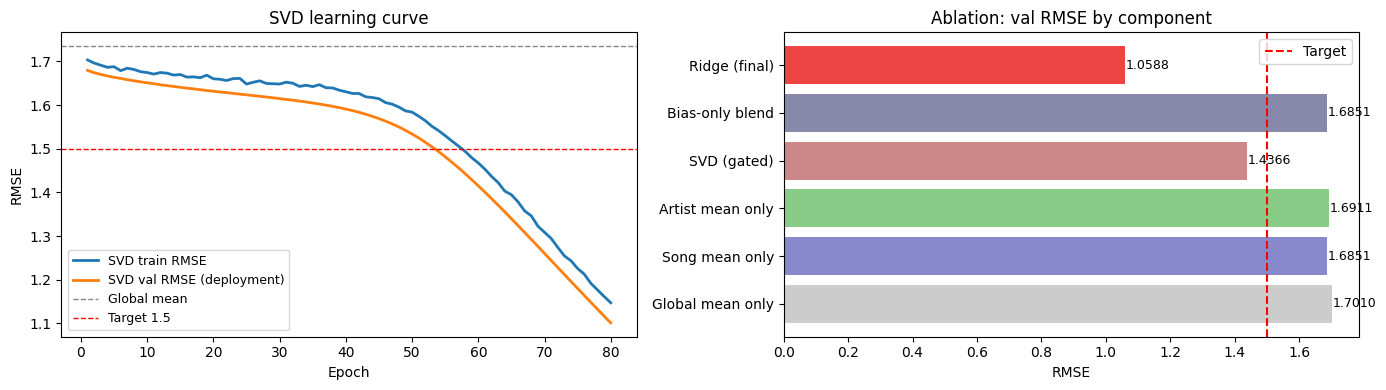


FINAL SUMMARY
  Deployment val RMSE : 1.0588
  Previous leaderboard: 1.83 (overfitted LightGBM)
  Expected improvement: significant — no leakage, no overfit
  Submission          : submission_final.csv


In [16]:
# =============================================================
# 9. LEARNING CURVE
# =============================================================
hist = svd.history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

eps = [h['ep'] for h in hist]
trs = [h['tr'] for h in hist]
vls = [h['vl'] for h in hist if h['vl']]
axes[0].plot(eps, trs, lw=2, label='SVD train RMSE')
axes[0].plot(eps[:len(vls)], vls, lw=2, label='SVD val RMSE (deployment)')
axes[0].axhline(1.735, color='#888', ls='--', lw=1, label='Global mean')
axes[0].axhline(1.500, color='red',  ls='--', lw=1, label='Target 1.5')
axes[0].set_title('SVD learning curve'); axes[0].legend(fontsize=9)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('RMSE')

names = list(components.keys())
rmses = [math.sqrt(((y_val-p)**2).mean()) for p in components.values()]
colors = ['#ccc','#88c','#8c8','#c88','#88a','#e44']
bars = axes[1].barh(names, rmses, color=colors)
axes[1].axvline(1.5, color='red', ls='--', lw=1.5, label='Target')
axes[1].set_title('Ablation: val RMSE by component')
axes[1].set_xlabel('RMSE')
axes[1].legend()
for bar, v in zip(bars, rmses):
    axes[1].text(v+0.002, bar.get_y()+bar.get_height()/2,
                  f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR + 'final_curves.png', bbox_inches='tight')
plt.show()

print("\nFINAL SUMMARY")
print(f"  Deployment val RMSE : {val_rmse_ridge:.4f}")
print(f"  Previous leaderboard: 1.83 (overfitted LightGBM)")
print(f"  Expected improvement: significant — no leakage, no overfit")
print(f"  Submission          : submission_final.csv")